In [1]:
# ── Core data libraries ──────────────────────────────────────────
import numpy as np               # numerical computing
import pandas as pd              # dataframes / data manipulation

# ── Visualisation ────────────────────────────────────────────────
import matplotlib.pyplot as plt  # base plotting
import seaborn as sns            # statistical charts (built on matplotlib)

# ── Statistics & Machine Learning ────────────────────────────────
from scipy import stats          # t-tests, statistical inference
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Settings ─────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)  # clean decimal display
pd.set_option("display.max_columns", 20)

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


In [2]:
# ── File path (update this if you move the file) ─────────────────
DATA_PATH = r"C:\Users\abuda\Downloads\archive\criteo-uplift-v2.1.csv"

# ── Sampling: we use 200k rows out of ~13.9M for speed ───────────
SAMPLE_SIZE = 200_000

# ── Random seed: ensures reproducibility ─────────────────────────
# Every time you run the notebook you'll get the exact same sample
SEED = 42

# ── Column names (as defined by Criteo) ──────────────────────────
FEATURE_COLS   = [f"f{i}" for i in range(12)]   # f0, f1, ..., f11
TREATMENT_COL  = "treatment"
EXPOSURE_COL   = "exposure"
VISIT_COL      = "visit"
CONVERSION_COL = "conversion"

print("✅ Configuration set.")
print(f"   Sample size : {SAMPLE_SIZE:,} rows")
print(f"   Random seed : {SEED}")
print(f"   Features    : {FEATURE_COLS}")

✅ Configuration set.
   Sample size : 200,000 rows
   Random seed : 42
   Features    : ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']


In [3]:
print("Loading data... (this may take 30–60 seconds)")

# Step 1: Read the full CSV — pandas handles the 340MB file
df_full = pd.read_csv(DATA_PATH)

print(f"   Full dataset shape : {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# Step 2: Randomly sample 200,000 rows
df = df_full.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

print(f"   Sampled dataset    : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n✅ Data loaded and sampled successfully.")

Loading data... (this may take 30–60 seconds)
   Full dataset shape : 13,979,592 rows × 16 columns
   Sampled dataset    : 200,000 rows × 16 columns

✅ Data loaded and sampled successfully.


In [4]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)

print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\n── Column names & data types ──")
print(df.dtypes)

print("\n── First 5 rows ──")
df.head()

DATASET OVERVIEW

Shape: 200,000 rows × 16 columns

── Column names & data types ──
f0            float64
f1            float64
f2            float64
f3            float64
f4            float64
f5            float64
f6            float64
f7            float64
f8            float64
f9            float64
f10           float64
f11           float64
treatment       int64
conversion      int64
visit           int64
exposure        int64
dtype: object

── First 5 rows ──


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,21.2655,10.0597,8.2144,4.6799,10.2805,4.1155,-12.6418,4.8338,3.9719,13.1901,5.3004,-0.1687,0,0,0,0
1,25.7443,10.0597,8.2144,4.6799,10.2805,4.1155,-3.2821,4.8338,3.9719,13.1901,5.3004,-0.1687,1,0,0,0
2,12.6164,10.0597,8.8135,4.6799,10.2805,4.1155,0.2944,4.8338,3.9065,13.1901,5.3004,-0.1687,1,0,0,0
3,12.6164,10.0597,8.8763,4.6799,10.2805,4.1155,0.2944,4.8338,3.8959,13.1901,5.3004,-0.1687,1,0,0,0
4,12.6164,10.0597,9.0071,4.6799,10.2805,4.1155,0.2944,4.8338,3.8901,13.1901,5.3004,-0.1687,1,0,0,0


In [5]:
print("=" * 55)
print("DATA QUALITY CHECK")
print("=" * 55)

# Missing values
missing = df.isnull().sum()
print(f"\n── Missing values per column ──")
print(missing[missing > 0] if missing.sum() > 0 else "   ✅ No missing values found.")

# Data ranges for key columns
print(f"\n── Key column value counts ──")
print(f"   treatment  : {dict(df[TREATMENT_COL].value_counts().sort_index())}")
print(f"   exposure   : {dict(df[EXPOSURE_COL].value_counts().sort_index())}")
print(f"   visit      : {dict(df[VISIT_COL].value_counts().sort_index())}")
print(f"   conversion : {dict(df[CONVERSION_COL].value_counts().sort_index())}")

# Summary statistics for features
print(f"\n── Feature summary statistics ──")
df[FEATURE_COLS].describe().round(3)

DATA QUALITY CHECK

── Missing values per column ──
   ✅ No missing values found.

── Key column value counts ──
   treatment  : {0: np.int64(30065), 1: np.int64(169935)}
   exposure   : {0: np.int64(193786), 1: np.int64(6214)}
   visit      : {0: np.int64(190485), 1: np.int64(9515)}
   conversion : {0: np.int64(199357), 1: np.int64(643)}

── Feature summary statistics ──


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
count,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000
mean,19.6290,10.0700,8.4460,4.1830,10.3390,4.0290,-4.1610,5.1020,3.9330,16.0420,5.3330,-0.1710
std,5.3750,0.1050,0.2990,1.3270,0.3460,0.4310,4.5810,1.2040,0.0570,7.0310,0.1670,0.0230
min,12.6160,10.0600,8.2140,-5.5880,10.2810,-5.4720,-25.9550,4.8340,3.6490,13.1900,5.3000,-1.0120
25%,12.6160,10.0600,8.2140,4.6800,10.2810,4.1150,-6.6990,4.8340,3.9110,13.1900,5.3000,-0.1690
50%,21.9290,10.0600,8.2140,4.6800,10.2810,4.1150,-2.4110,4.8340,3.9720,13.1900,5.3000,-0.1690
75%,24.4320,10.0600,8.7180,4.6800,10.2810,4.1150,0.2940,4.8340,3.9720,13.1900,5.3000,-0.1690
max,26.7450,13.5800,9.0520,4.6800,19.0060,4.1150,0.2940,11.9980,3.9720,72.6570,6.4740,-0.1690


In [6]:
print("=" * 55)
print("SAMPLE REPRESENTATIVENESS CHECK")
print("=" * 55)

n = len(df)
n_treated = df[TREATMENT_COL].sum()
n_control = n - n_treated

print(f"""
   Total users      : {n:,}

   Treatment group  : {n_treated:,}  ({100 * n_treated / n:.1f}%)
   Control group    : {n_control:,}  ({100 * n_control / n:.1f}%)

   Visit rate       : {df[VISIT_COL].mean():.4f}  (expected ~0.047)
   Conversion rate  : {df[CONVERSION_COL].mean():.4f}  (expected ~0.003)
   Exposure rate    : {df[EXPOSURE_COL].mean():.4f}

   ── Rates by group ──
   Visit rate   | Treated: {df[df[TREATMENT_COL]==1][VISIT_COL].mean():.4f}  |  Control: {df[df[TREATMENT_COL]==0][VISIT_COL].mean():.4f}
   Conv. rate   | Treated: {df[df[TREATMENT_COL]==1][CONVERSION_COL].mean():.4f}  |  Control: {df[df[TREATMENT_COL]==0][CONVERSION_COL].mean():.4f}
""")

# Raw uplift preview (we'll test this properly in Step 3)
raw_uplift_visit = (df[df[TREATMENT_COL]==1][VISIT_COL].mean() 
                  - df[df[TREATMENT_COL]==0][VISIT_COL].mean())
raw_uplift_conv  = (df[df[TREATMENT_COL]==1][CONVERSION_COL].mean() 
                  - df[df[TREATMENT_COL]==0][CONVERSION_COL].mean())

print(f"   Raw uplift (visit)      : {raw_uplift_visit:+.4f}")
print(f"   Raw uplift (conversion) : {raw_uplift_conv:+.4f}")
print("\n✅ Step 1 complete. Data is ready for analysis.")

SAMPLE REPRESENTATIVENESS CHECK

   Total users      : 200,000

   Treatment group  : 169,935  (85.0%)
   Control group    : 30,065  (15.0%)

   Visit rate       : 0.0476  (expected ~0.047)
   Conversion rate  : 0.0032  (expected ~0.003)
   Exposure rate    : 0.0311

   ── Rates by group ──
   Visit rate   | Treated: 0.0491  |  Control: 0.0388
   Conv. rate   | Treated: 0.0035  |  Control: 0.0018

   Raw uplift (visit)      : +0.0103
   Raw uplift (conversion) : +0.0017

✅ Step 1 complete. Data is ready for analysis.


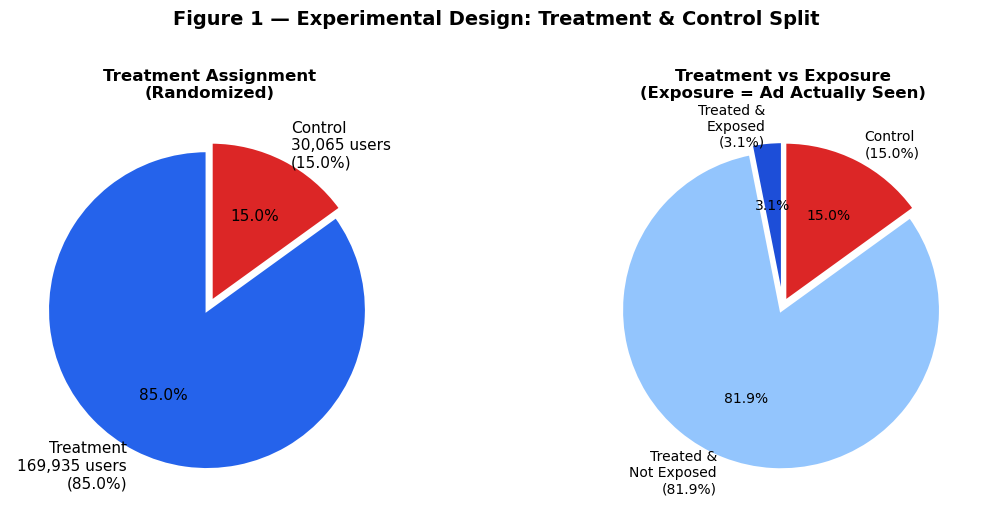

✅ Figure 1 saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Figure 1 — Experimental Design: Treatment & Control Split", 
             fontsize=14, fontweight="bold", y=1.02)

# ── Left: Treatment split pie chart ──────────────────────────────
n = len(df)
n_treated = df[TREATMENT_COL].sum()
n_control = n - n_treated

sizes  = [n_treated, n_control]
labels = [f"Treatment\n{n_treated:,} users\n({100*n_treated/n:.1f}%)",
          f"Control\n{n_control:,} users\n({100*n_control/n:.1f}%)"]
colors = ["#2563EB", "#DC2626"]
explode = (0.03, 0.03)

axes[0].pie(sizes, labels=labels, colors=colors, explode=explode,
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11},
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Treatment Assignment\n(Randomized)", fontweight="bold")

# ── Right: Exposure within treatment group ────────────────────────
# Remember: treatment = ad auction entered, exposure = ad actually seen
exposed     = df[(df[TREATMENT_COL]==1) & (df[EXPOSURE_COL]==1)]
not_exposed = df[(df[TREATMENT_COL]==1) & (df[EXPOSURE_COL]==0)]

sizes2  = [len(exposed), len(not_exposed), n_control]
labels2 = [f"Treated &\nExposed\n({100*len(exposed)/n:.1f}%)",
           f"Treated &\nNot Exposed\n({100*len(not_exposed)/n:.1f}%)",
           f"Control\n({100*n_control/n:.1f}%)"]
colors2 = ["#1D4ED8", "#93C5FD", "#DC2626"]

axes[1].pie(sizes2, labels=labels2, colors=colors2, explode=(0.03,0.03,0.03),
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 10},
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Treatment vs Exposure\n(Exposure = Ad Actually Seen)", 
                  fontweight="bold")

plt.tight_layout()
plt.savefig("fig1_treatment_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 1 saved.")

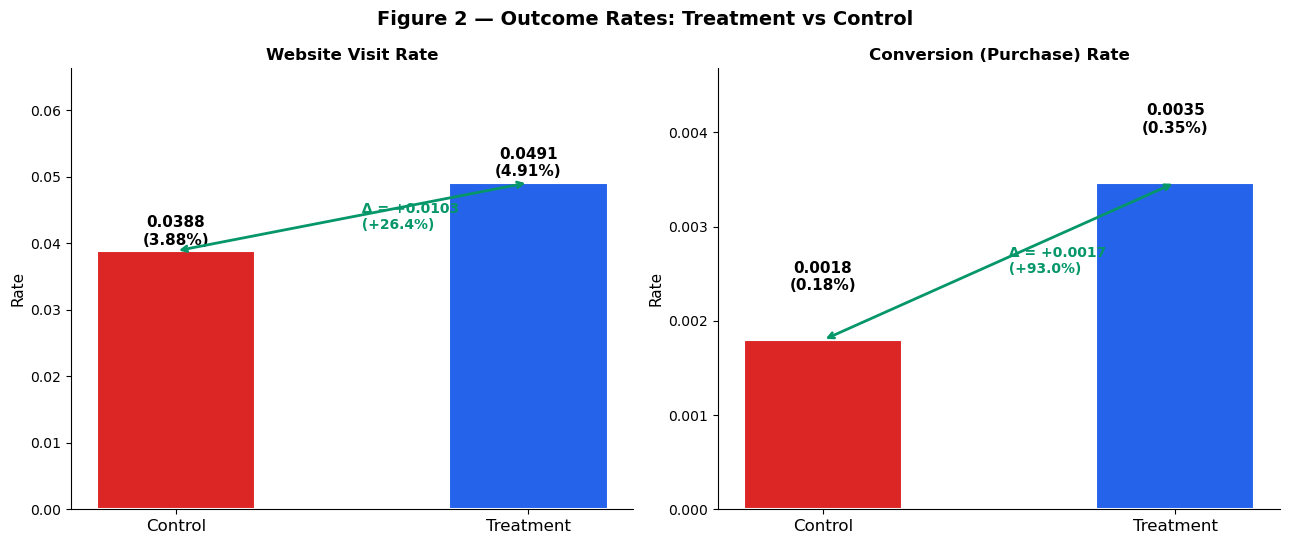

✅ Figure 2 saved.

── Outcome Summary Table ──────────────────────────────────
        Group Visit Rate Conversion Rate
      Control     0.0388          0.0018
    Treatment     0.0491          0.0035
   Uplift (Δ)    +0.0103         +0.0017
Relative Lift     +26.4%          +93.0%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("Figure 2 — Outcome Rates: Treatment vs Control", 
             fontsize=14, fontweight="bold")

groups      = ["Control", "Treatment"]
colors_bar  = ["#DC2626", "#2563EB"]

for ax, outcome, title, expected in zip(
    axes,
    [VISIT_COL, CONVERSION_COL],
    ["Website Visit Rate", "Conversion (Purchase) Rate"],
    [0.047, 0.003]
):
    rates = [
        df[df[TREATMENT_COL]==0][outcome].mean(),
        df[df[TREATMENT_COL]==1][outcome].mean()
    ]

    bars = ax.bar(groups, rates, color=colors_bar, 
                  width=0.45, edgecolor="white", linewidth=1.5)

    # Value labels on bars
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0005,
                f"{rate:.4f}\n({rate*100:.2f}%)",
                ha="center", va="bottom", fontsize=11, fontweight="bold")

    # Uplift annotation arrow
    uplift = rates[1] - rates[0]
    ax.annotate("", 
                xy=(1, rates[1]),
                xytext=(0, rates[0]),
                arrowprops=dict(arrowstyle="<->", color="#059669", lw=2))
    ax.text(0.5, (rates[0] + rates[1])/2,
            f"  Δ = {uplift:+.4f}\n  ({uplift/rates[0]*100:+.1f}%)",
            ha="left", va="center", fontsize=10, color="#059669", fontweight="bold")

    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_ylabel("Rate", fontsize=11)
    ax.set_ylim(0, max(rates) * 1.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.savefig("fig2_outcome_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2 saved.")

# Print a clean summary table
print("\n── Outcome Summary Table ──────────────────────────────────")
summary = pd.DataFrame({
    "Group"      : ["Control", "Treatment", "Uplift (Δ)", "Relative Lift"],
    "Visit Rate" : [
        f"{df[df[TREATMENT_COL]==0][VISIT_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==1][VISIT_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==1][VISIT_COL].mean() - df[df[TREATMENT_COL]==0][VISIT_COL].mean():+.4f}",
        f"{(df[df[TREATMENT_COL]==1][VISIT_COL].mean() / df[df[TREATMENT_COL]==0][VISIT_COL].mean() - 1)*100:+.1f}%"
    ],
    "Conversion Rate" : [
        f"{df[df[TREATMENT_COL]==0][CONVERSION_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==1][CONVERSION_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==1][CONVERSION_COL].mean() - df[df[TREATMENT_COL]==0][CONVERSION_COL].mean():+.4f}",
        f"{(df[df[TREATMENT_COL]==1][CONVERSION_COL].mean() / df[df[TREATMENT_COL]==0][CONVERSION_COL].mean() - 1)*100:+.1f}%"
    ]
})
print(summary.to_string(index=False))

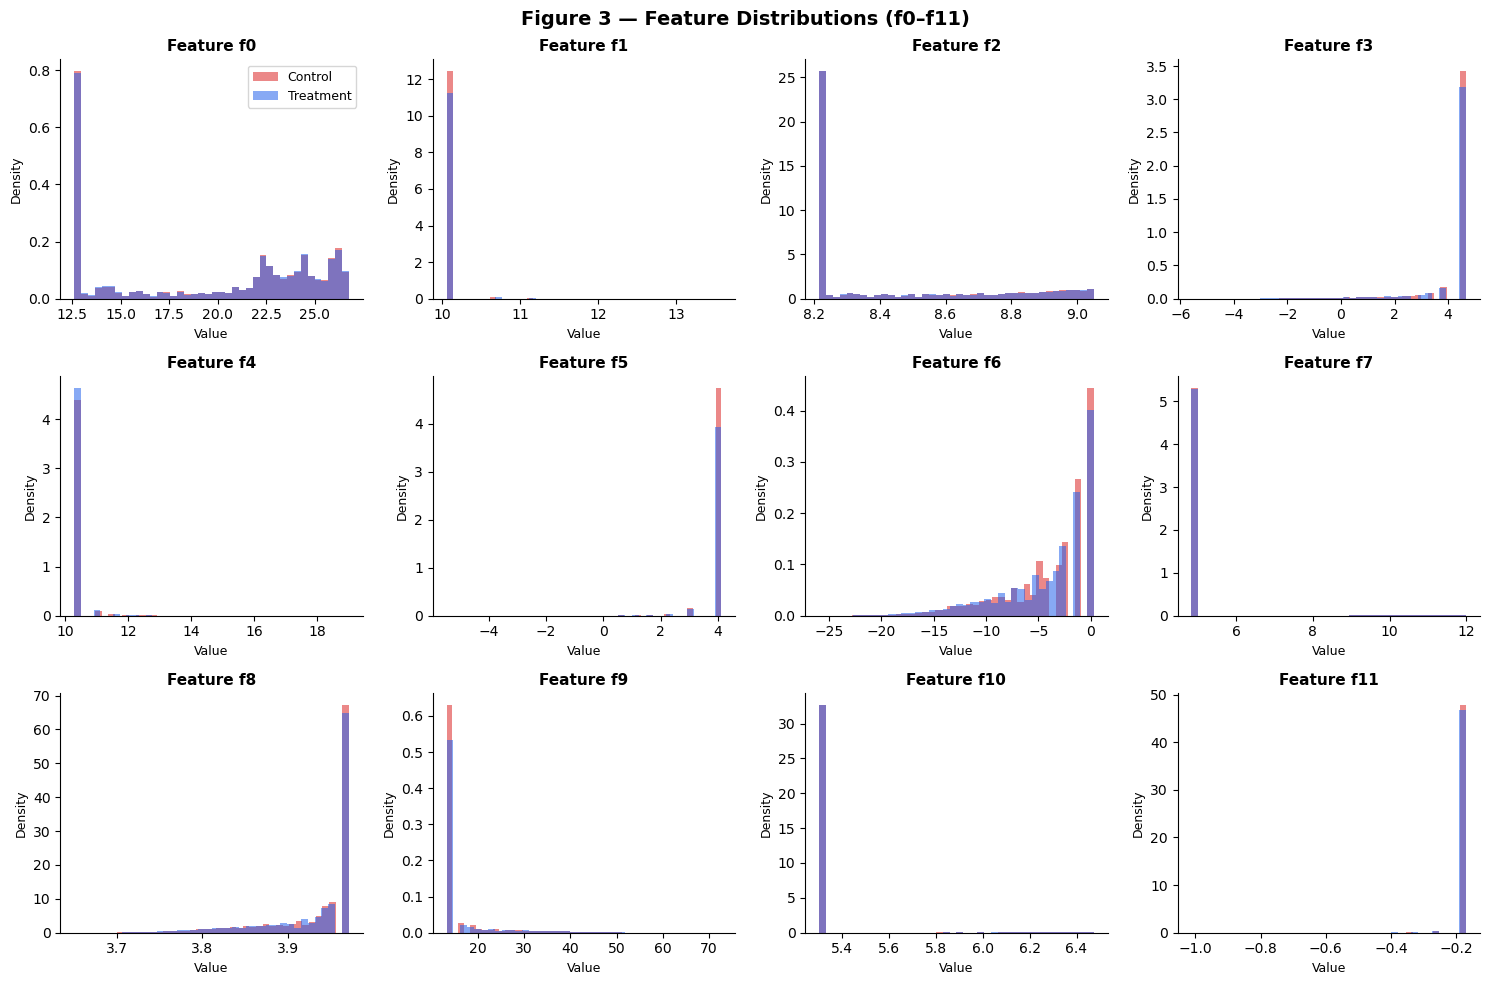

✅ Figure 3 saved.


In [9]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
fig.suptitle("Figure 3 — Feature Distributions (f0–f11)", 
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    
    # Plot treated and control separately to spot differences
    ax.hist(df[df[TREATMENT_COL]==0][col], bins=40, alpha=0.55,
            color="#DC2626", label="Control", density=True)
    ax.hist(df[df[TREATMENT_COL]==1][col], bins=40, alpha=0.55,
            color="#2563EB", label="Treatment", density=True)
    
    ax.set_title(f"Feature {col}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    if i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig3_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 3 saved.")

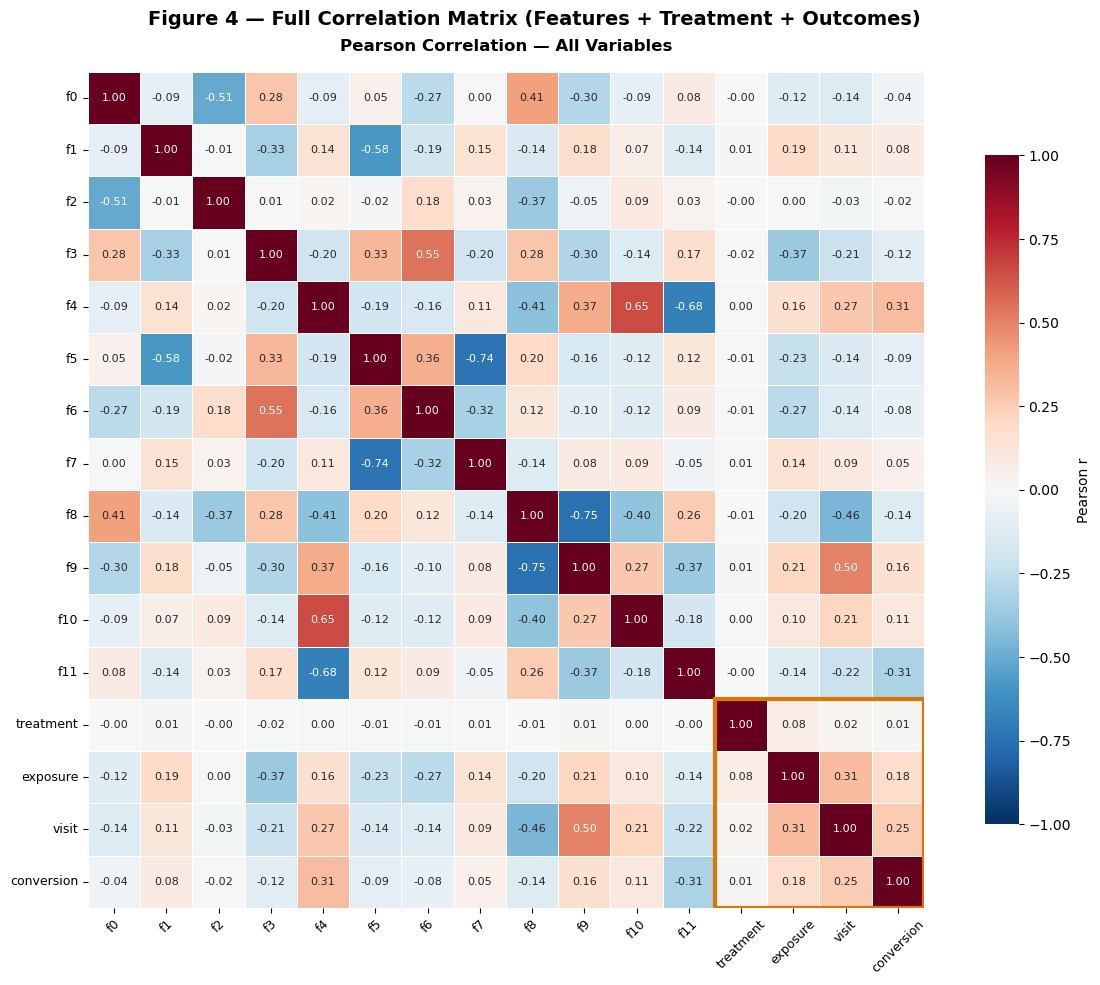

✅ Figure 4 updated and saved.

── Correlations WITH outcomes and treatment ──────────────────
     treatment  exposure   visit  conversion
f0     -0.0021   -0.1245 -0.1372     -0.0421
f1      0.0093    0.1931  0.1135      0.0816
f2     -0.0029    0.0044 -0.0297     -0.0151
f3     -0.0151   -0.3718 -0.2125     -0.1153
f4      0.0048    0.1636  0.2732      0.3092
f5     -0.0122   -0.2276 -0.1420     -0.0943
f6     -0.0139   -0.2680 -0.1396     -0.0809
f7      0.0070    0.1433  0.0950      0.0476
f8     -0.0075   -0.2024 -0.4595     -0.1363
f9      0.0088    0.2077  0.4965      0.1621
f10     0.0037    0.1043  0.2112      0.1080
f11    -0.0035   -0.1377 -0.2198     -0.3125


In [12]:
fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle("Figure 4 — Full Correlation Matrix (Features + Treatment + Outcomes)",
             fontsize=14, fontweight="bold")

# Now include treatment, exposure, visit, conversion
ALL_COLS = FEATURE_COLS + [TREATMENT_COL, EXPOSURE_COL, VISIT_COL, CONVERSION_COL]

corr_matrix = df[ALL_COLS].corr()

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    annot_kws={"size": 8}
)

# Draw a box to highlight the outcome columns visually
ax.add_patch(plt.Rectangle(
    (12, 12), 4, 4,          # x, y, width, height (in cell units)
    fill=False,
    edgecolor="#D97706",
    lw=3,
    label="Outcome & Treatment block"
))

ax.set_title("Pearson Correlation — All Variables", 
             fontsize=12, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig("fig4_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 4 updated and saved.")

# ── Print the most informative correlations ───────────────────────────────────
print("\n── Correlations WITH outcomes and treatment ──────────────────")
outcome_cols = [TREATMENT_COL, EXPOSURE_COL, VISIT_COL, CONVERSION_COL]
corr_with_outcomes = corr_matrix[outcome_cols].drop(index=outcome_cols)
print(corr_with_outcomes.round(4).to_string())

In [11]:
print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

summary_eda = pd.DataFrame({
    "Metric": [
        "Total users (sample)",
        "Treatment group",
        "Control group",
        "Overall visit rate",
        "Overall conversion rate",
        "Visit rate — Control",
        "Visit rate — Treatment",
        "Raw visit uplift",
        "Conversion rate — Control",
        "Conversion rate — Treatment",
        "Raw conversion uplift",
        "Missing values",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df[TREATMENT_COL].sum():,}  ({100*df[TREATMENT_COL].mean():.1f}%)",
        f"{(1-df[TREATMENT_COL]).sum():,}  ({100*(1-df[TREATMENT_COL].mean()):.1f}%)",
        f"{df[VISIT_COL].mean():.4f}",
        f"{df[CONVERSION_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==0][VISIT_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==1][VISIT_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==1][VISIT_COL].mean() - df[df[TREATMENT_COL]==0][VISIT_COL].mean():+.4f}",
        f"{df[df[TREATMENT_COL]==0][CONVERSION_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==1][CONVERSION_COL].mean():.4f}",
        f"{df[df[TREATMENT_COL]==1][CONVERSION_COL].mean() - df[df[TREATMENT_COL]==0][CONVERSION_COL].mean():+.4f}",
        "None",
    ]
})

print(summary_eda.to_string(index=False))
print("\n✅ Step 2 — EDA complete. 4 figures saved.")

EDA SUMMARY — KEY FINDINGS
                     Metric            Value
       Total users (sample)          200,000
            Treatment group 169,935  (85.0%)
              Control group  30,065  (15.0%)
         Overall visit rate           0.0476
    Overall conversion rate           0.0032
       Visit rate — Control           0.0388
     Visit rate — Treatment           0.0491
           Raw visit uplift          +0.0103
  Conversion rate — Control           0.0018
Conversion rate — Treatment           0.0035
      Raw conversion uplift          +0.0017
             Missing values             None

✅ Step 2 — EDA complete. 4 figures saved.


In [13]:
print("=" * 60)
print("STEP 3 — AVERAGE TREATMENT EFFECT (ATE) ESTIMATION")
print("=" * 60)

# ── Separate treated and control outcomes ─────────────────────────
visit_treated = df[df[TREATMENT_COL] == 1][VISIT_COL].values
visit_control = df[df[TREATMENT_COL] == 0][VISIT_COL].values

conv_treated  = df[df[TREATMENT_COL] == 1][CONVERSION_COL].values
conv_control  = df[df[TREATMENT_COL] == 0][CONVERSION_COL].values

# ── ATE: simple difference in means ──────────────────────────────
ate_visit = visit_treated.mean() - visit_control.mean()
ate_conv  = conv_treated.mean()  - conv_control.mean()

# ── Two-sample t-test ─────────────────────────────────────────────
# Null hypothesis H0: ATE = 0  (the ad has no effect)
# Alternative  H1: ATE ≠ 0  (the ad has an effect)
t_stat_v, p_val_v = stats.ttest_ind(visit_treated, visit_control)
t_stat_c, p_val_c = stats.ttest_ind(conv_treated,  conv_control)

# ── 95% Confidence Interval (manual) ─────────────────────────────
# CI = ATE ± 1.96 × SE,  where SE = sqrt(var1/n1 + var2/n2)
def confidence_interval_95(g1, g2):
    se = np.sqrt(g1.var()/len(g1) + g2.var()/len(g2))
    margin = 1.96 * se
    return ate_visit - margin, ate_visit + margin  

se_visit = np.sqrt(visit_treated.var()/len(visit_treated) + 
                   visit_control.var()/len(visit_control))
ci_visit_low  = ate_visit - 1.96 * se_visit
ci_visit_high = ate_visit + 1.96 * se_visit

se_conv  = np.sqrt(conv_treated.var()/len(conv_treated) + 
                   conv_control.var()/len(conv_control))
ci_conv_low   = ate_conv - 1.96 * se_conv
ci_conv_high  = ate_conv + 1.96 * se_conv

# ── Cohen's h: effect size for proportions ───────────────────────
# h < 0.2: small,  h 0.2–0.5: medium,  h > 0.5: large
def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

h_visit = abs(cohens_h(visit_treated.mean(), visit_control.mean()))
h_conv  = abs(cohens_h(conv_treated.mean(),  conv_control.mean()))

# ── Print Results ─────────────────────────────────────────────────
print(f"""
  ── VISIT OUTCOME ─────────────────────────────────────
  Control  visit rate        : {visit_control.mean():.4f}
  Treatment visit rate       : {visit_treated.mean():.4f}
  
  ATE (visit)                : {ate_visit:+.4f}
  95% Confidence Interval    : [{ci_visit_low:+.4f},  {ci_visit_high:+.4f}]
  t-statistic                : {t_stat_v:.4f}
  p-value                    : {p_val_v:.6f}
  Cohen's h (effect size)    : {h_visit:.4f}  ({'small' if h_visit < 0.2 else 'medium' if h_visit < 0.5 else 'large'})
  Statistically significant? : {'✅ YES (p < 0.05)' if p_val_v < 0.05 else '❌ NO (p ≥ 0.05)'}

  ── CONVERSION OUTCOME ────────────────────────────────
  Control  conversion rate   : {conv_control.mean():.4f}
  Treatment conversion rate  : {conv_treated.mean():.4f}
  
  ATE (conversion)           : {ate_conv:+.4f}
  95% Confidence Interval    : [{ci_conv_low:+.4f},  {ci_conv_high:+.4f}]
  t-statistic                : {t_stat_c:.4f}
  p-value                    : {p_val_c:.6f}
  Cohen's h (effect size)    : {h_conv:.4f}  ({'small' if h_conv < 0.2 else 'medium' if h_conv < 0.5 else 'large'})
  Statistically significant? : {'✅ YES (p < 0.05)' if p_val_c < 0.05 else '❌ NO (p ≥ 0.05)'}
""")

STEP 3 — AVERAGE TREATMENT EFFECT (ATE) ESTIMATION

  ── VISIT OUTCOME ─────────────────────────────────────
  Control  visit rate        : 0.0388
  Treatment visit rate       : 0.0491
  
  ATE (visit)                : +0.0103
  95% Confidence Interval    : [+0.0079,  +0.0127]
  t-statistic                : 7.7120
  p-value                    : 0.000000
  Cohen's h (effect size)    : 0.0502  (small)
  Statistically significant? : ✅ YES (p < 0.05)

  ── CONVERSION OUTCOME ────────────────────────────────
  Control  conversion rate   : 0.0018
  Treatment conversion rate  : 0.0035
  
  ATE (conversion)           : +0.0017
  95% Confidence Interval    : [+0.0011,  +0.0022]
  t-statistic                : 4.7150
  p-value                    : 0.000002
  Cohen's h (effect size)    : 0.0330  (small)
  Statistically significant? : ✅ YES (p < 0.05)



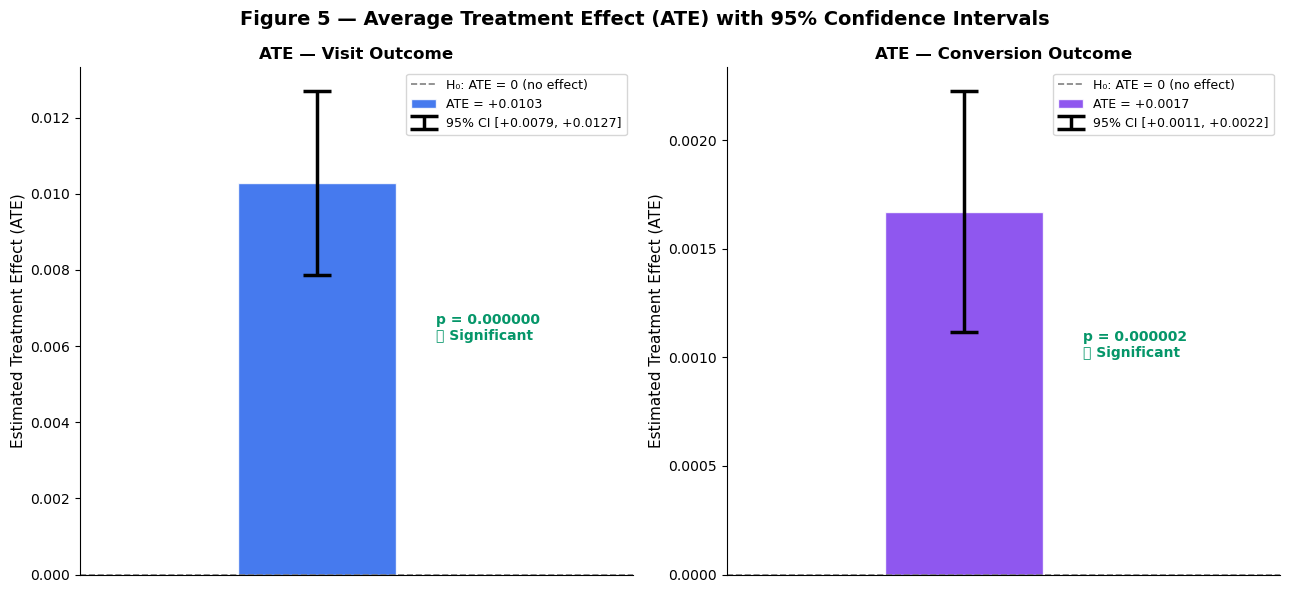

✅ Figure 5 saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Figure 5 — Average Treatment Effect (ATE) with 95% Confidence Intervals",
             fontsize=14, fontweight="bold")

outcomes = ["Visit", "Conversion"]
ates     = [ate_visit,    ate_conv]
ci_lows  = [ci_visit_low, ci_conv_low]
ci_highs = [ci_visit_high, ci_conv_high]
p_vals   = [p_val_v,      p_val_c]
colors   = ["#2563EB",    "#7C3AED"]

for ax, outcome, ate, ci_low, ci_high, pval, color in zip(
    axes, outcomes, ates, ci_lows, ci_highs, p_vals, colors
):
    # ── Bar: ATE estimate ─────────────────────────────────────────
    ax.bar(0, ate, width=0.4, color=color, alpha=0.85,
           edgecolor="white", label=f"ATE = {ate:+.4f}")

    # ── Error bar: 95% CI ─────────────────────────────────────────
    ax.errorbar(0, ate,
                yerr=[[ate - ci_low], [ci_high - ate]],
                fmt="none", color="black", capsize=10,
                capthick=2.5, elinewidth=2.5,
                label=f"95% CI [{ci_low:+.4f}, {ci_high:+.4f}]")

    # ── Zero line: no effect reference ───────────────────────────
    ax.axhline(0, color="gray", linestyle="--", linewidth=1.2, 
               label="H₀: ATE = 0 (no effect)")

    # ── Significance annotation ───────────────────────────────────
    sig_text = f"p = {pval:.6f}\n{'✅ Significant' if pval < 0.05 else '❌ Not significant'}"
    ax.text(0.3, ate * 0.6, sig_text,
            fontsize=10, color="#059669" if pval < 0.05 else "#DC2626",
            fontweight="bold")

    ax.set_title(f"ATE — {outcome} Outcome", fontweight="bold", fontsize=12)
    ax.set_ylabel("Estimated Treatment Effect (ATE)", fontsize=11)
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.8)
    ax.legend(fontsize=9, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig5_ate_confidence_intervals.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 5 saved.")

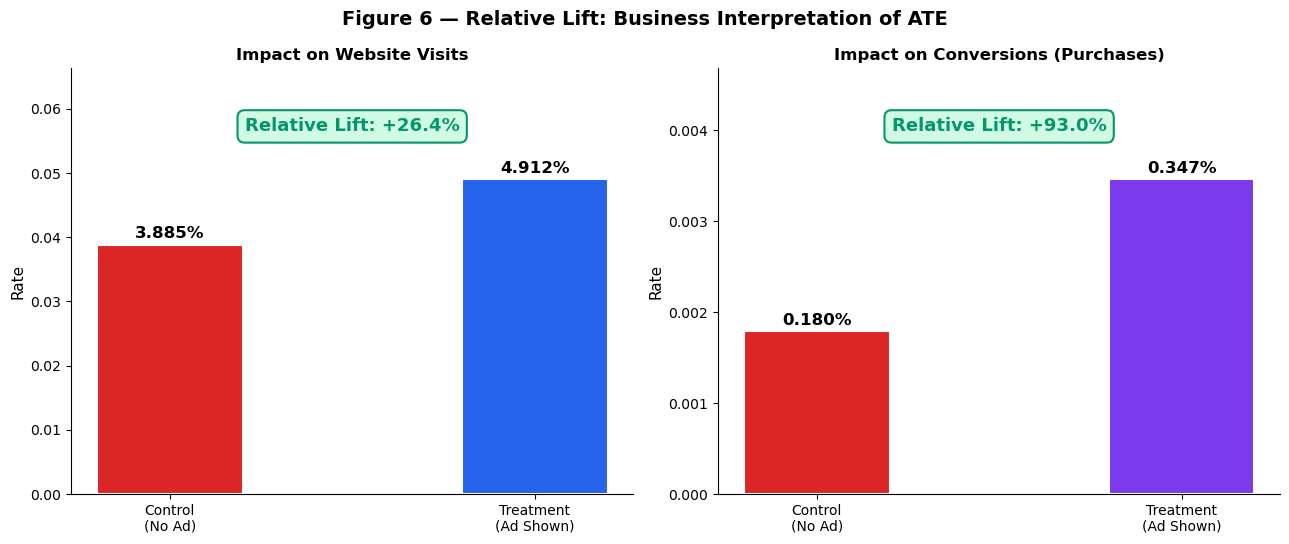

✅ Figure 6 saved.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("Figure 6 — Relative Lift: Business Interpretation of ATE",
             fontsize=14, fontweight="bold")

for ax, outcome, title, treated_rate, control_rate, color in zip(
    axes,
    [VISIT_COL,   CONVERSION_COL],
    ["Website Visits", "Conversions (Purchases)"],
    [visit_treated.mean(), conv_treated.mean()],
    [visit_control.mean(), conv_control.mean()],
    ["#2563EB", "#7C3AED"]
):
    rel_lift = (treated_rate - control_rate) / control_rate * 100

    categories = ["Control\n(No Ad)", "Treatment\n(Ad Shown)"]
    rates      = [control_rate, treated_rate]
    bar_colors = ["#DC2626", color]

    bars = ax.bar(categories, rates, color=bar_colors,
                  width=0.4, edgecolor="white", linewidth=1.5)

    # Value labels
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(rates)*0.01,
                f"{rate*100:.3f}%",
                ha="center", va="bottom",
                fontsize=12, fontweight="bold")

    # Relative lift badge
    ax.text(0.5, max(rates) * 1.15,
            f"Relative Lift: {rel_lift:+.1f}%",
            ha="center", fontsize=13, fontweight="bold",
            color="#059669",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#D1FAE5",
                      edgecolor="#059669", linewidth=1.5))

    ax.set_title(f"Impact on {title}", fontweight="bold", fontsize=12)
    ax.set_ylabel("Rate", fontsize=11)
    ax.set_ylim(0, max(rates) * 1.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig6_relative_lift.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 6 saved.")

In [16]:
print("=" * 60)
print("STEP 3 SUMMARY — ATE RESULTS")
print("=" * 60)

ate_summary = pd.DataFrame({
    "Metric"            : [
        "Control Rate", "Treatment Rate", "ATE",
        "95% CI (Lower)", "95% CI (Upper)",
        "Relative Lift", "t-statistic",
        "p-value", "Effect Size (Cohen's h)",
        "Significant (α=0.05)?"
    ],
    "Visit"      : [
        f"{visit_control.mean():.4f}",
        f"{visit_treated.mean():.4f}",
        f"{ate_visit:+.4f}",
        f"{ci_visit_low:+.4f}",
        f"{ci_visit_high:+.4f}",
        f"{(ate_visit/visit_control.mean())*100:+.2f}%",
        f"{t_stat_v:.4f}",
        f"{p_val_v:.6f}",
        f"{h_visit:.4f}",
        "YES ✅" if p_val_v < 0.05 else "NO ❌"
    ],
    "Conversion" : [
        f"{conv_control.mean():.4f}",
        f"{conv_treated.mean():.4f}",
        f"{ate_conv:+.4f}",
        f"{ci_conv_low:+.4f}",
        f"{ci_conv_high:+.4f}",
        f"{(ate_conv/conv_control.mean())*100:+.2f}%",
        f"{t_stat_c:.4f}",
        f"{p_val_c:.6f}",
        f"{h_conv:.4f}",
        "YES ✅" if p_val_c < 0.05 else "NO ❌"
    ]
})

print(ate_summary.to_string(index=False))
print("\n✅ Step 3 — ATE complete. Figures 5 & 6 saved.")

STEP 3 SUMMARY — ATE RESULTS
                 Metric    Visit Conversion
           Control Rate   0.0388     0.0018
         Treatment Rate   0.0491     0.0035
                    ATE  +0.0103    +0.0017
         95% CI (Lower)  +0.0079    +0.0011
         95% CI (Upper)  +0.0127    +0.0022
          Relative Lift  +26.43%    +92.97%
            t-statistic   7.7120     4.7150
                p-value 0.000000   0.000002
Effect Size (Cohen's h)   0.0502     0.0330
  Significant (α=0.05)?    YES ✅      YES ✅

✅ Step 3 — ATE complete. Figures 5 & 6 saved.


In [17]:
print("=" * 60)
print("STEP 4 — INVERSE PROBABILITY WEIGHTING (IPW)")
print("=" * 60)

# ── Prepare features and treatment label ──────────────────────────
X = df[FEATURE_COLS].values
D = df[TREATMENT_COL].values   # treatment indicator
Y_visit  = df[VISIT_COL].values
Y_conv   = df[CONVERSION_COL].values

# ── Scale features ────────────────────────────────────────────────
# Logistic Regression is sensitive to feature scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train/test split ──────────────────────────────────────────────
# We split so we can evaluate the propensity model honestly
X_train, X_test, D_train, D_test = train_test_split(
    X_scaled, D, test_size=0.3, random_state=SEED
)

# ── Fit Logistic Regression to predict treatment ──────────────────
propensity_model = LogisticRegression(
    max_iter=1000, 
    random_state=SEED,
    C=1.0          # regularisation strength
)
propensity_model.fit(X_train, D_train)

# ── Predict propensity scores for ALL users ───────────────────────
# e(x) = P(treatment=1 | X=x)
propensity_scores = propensity_model.predict_proba(X_scaled)[:, 1]

# ── Evaluate the propensity model ─────────────────────────────────
D_test_pred = propensity_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(D_test, D_test_pred)

print(f"""
  Propensity Score Model: Logistic Regression
  Features used         : f0 – f11 (scaled)
  Training samples      : {len(X_train):,}
  Test samples          : {len(X_test):,}

  ── Propensity Score Distribution ──
  Mean  (treated) : {propensity_scores[D==1].mean():.4f}
  Mean  (control) : {propensity_scores[D==0].mean():.4f}
  Min             : {propensity_scores.min():.4f}
  Max             : {propensity_scores.max():.4f}

  ── Model Quality ──
  AUC-ROC         : {auc:.4f}
  
  Note: AUC near 0.5 is actually GOOD here — it means
  treatment was close to random (as expected in an RCT).
  A high AUC would suggest treatment was NOT random.
""")

STEP 4 — INVERSE PROBABILITY WEIGHTING (IPW)

  Propensity Score Model: Logistic Regression
  Features used         : f0 – f11 (scaled)
  Training samples      : 140,000
  Test samples          : 60,000

  ── Propensity Score Distribution ──
  Mean  (treated) : 0.8501
  Mean  (control) : 0.8497
  Min             : 0.8274
  Max             : 0.9485

  ── Model Quality ──
  AUC-ROC         : 0.5089
  
  Note: AUC near 0.5 is actually GOOD here — it means
  treatment was close to random (as expected in an RCT).
  A high AUC would suggest treatment was NOT random.



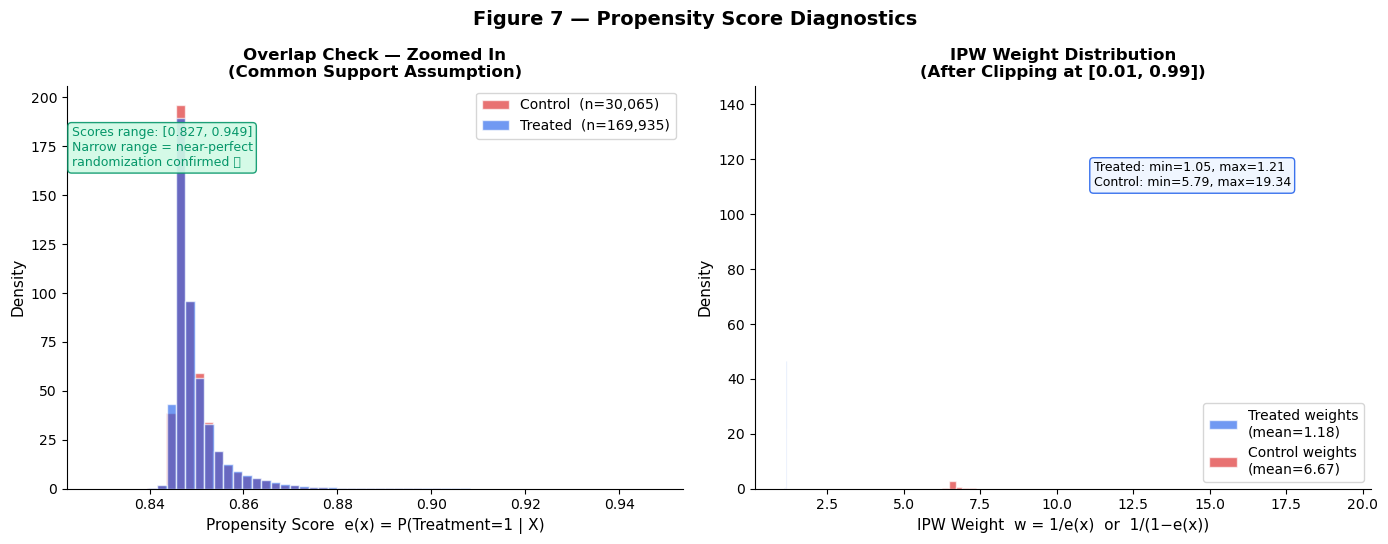

✅ Figure 7 fixed and saved.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Figure 7 — Propensity Score Diagnostics",
             fontsize=14, fontweight="bold")

# ── Left: Overlapping distributions — ZOOMED IN ───────────────────
ax = axes[0]
ps_control = propensity_scores[D==0]
ps_treated = propensity_scores[D==1]

ax.hist(ps_control, bins=60, alpha=0.65,
        color="#DC2626", label=f"Control  (n={int((D==0).sum()):,})",
        density=True, edgecolor="white")
ax.hist(ps_treated, bins=60, alpha=0.65,
        color="#2563EB", label=f"Treated  (n={int((D==1).sum()):,})",
        density=True, edgecolor="white")

# Zoom x-axis to where the data actually lives
ps_min = propensity_scores.min() - 0.005
ps_max = propensity_scores.max() + 0.005
ax.set_xlim(ps_min, ps_max)

ax.set_xlabel("Propensity Score  e(x) = P(Treatment=1 | X)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Overlap Check — Zoomed In\n(Common Support Assumption)", 
             fontweight="bold")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotation explaining the narrow range
ax.text(ps_min + 0.001, ax.get_ylim()[1] * 0.80,
        f"Scores range: [{ps_min+0.005:.3f}, {ps_max-0.005:.3f}]\n"
        f"Narrow range = near-perfect\nrandomization confirmed ✅",
        fontsize=9, color="#059669",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#D1FAE5",
                  edgecolor="#059669", alpha=0.9))

# ── Right: IPW weights distribution ──────────────────────────────
ax2 = axes[1]
eps = 0.01
ps_clipped = np.clip(propensity_scores, eps, 1 - eps)

weights_treated = 1.0 / ps_clipped[D==1]
weights_control = 1.0 / (1.0 - ps_clipped[D==0])

ax2.hist(weights_treated, bins=60, alpha=0.65,
         color="#2563EB", label=f"Treated weights\n(mean={weights_treated.mean():.2f})",
         density=True, edgecolor="white")
ax2.hist(weights_control, bins=60, alpha=0.65,
         color="#DC2626", label=f"Control weights\n(mean={weights_control.mean():.2f})",
         density=True, edgecolor="white")

ax2.set_xlabel("IPW Weight  w = 1/e(x)  or  1/(1−e(x))", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("IPW Weight Distribution\n(After Clipping at [0.01, 0.99])",
              fontweight="bold")
ax2.legend(fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Summary stats on chart
ax2.text(0.55, 0.75,
         f"Treated: min={weights_treated.min():.2f}, max={weights_treated.max():.2f}\n"
         f"Control: min={weights_control.min():.2f}, max={weights_control.max():.2f}",
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#EFF6FF",
                   edgecolor="#2563EB", alpha=0.9))

plt.tight_layout()
plt.savefig("fig7_propensity_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 7 fixed and saved.")

In [20]:
print("=" * 60)
print("IPW — ATE ESTIMATION")
print("=" * 60)

# ── Clip propensity scores to avoid extreme weights ───────────────
# Standard practice: clip at [0.01, 0.99] to prevent instability
eps = 0.01
ps_clipped = np.clip(propensity_scores, eps, 1 - eps)

# ── Compute IPW weights ───────────────────────────────────────────
# Treated:  w = 1/e(x)
# Control:  w = 1/(1-e(x))
weights = np.where(D == 1, 
                   1.0 / ps_clipped, 
                   1.0 / (1.0 - ps_clipped))

# ── IPW ATE formula ───────────────────────────────────────────────
def ipw_ate(Y, D, weights):
    # Weighted mean for treated minus weighted mean for control
    treated_wmean = np.sum(weights[D==1] * Y[D==1]) / np.sum(weights[D==1])
    control_wmean = np.sum(weights[D==0] * Y[D==0]) / np.sum(weights[D==0])
    return treated_wmean - control_wmean, treated_wmean, control_wmean

ipw_ate_visit, ipw_visit_t, ipw_visit_c = ipw_ate(Y_visit, D, weights)
ipw_ate_conv,  ipw_conv_t,  ipw_conv_c  = ipw_ate(Y_conv,  D, weights)

print(f"""
  ── VISIT OUTCOME ───────────────────────────────────────
  IPW weighted mean (treated) : {ipw_visit_t:.4f}
  IPW weighted mean (control) : {ipw_visit_c:.4f}
  IPW ATE (visit)             : {ipw_ate_visit:+.4f}
  Naive ATE (Step 3)          : {ate_visit:+.4f}
  Difference                  : {ipw_ate_visit - ate_visit:+.4f}

  ── CONVERSION OUTCOME ──────────────────────────────────
  IPW weighted mean (treated) : {ipw_conv_t:.4f}
  IPW weighted mean (control) : {ipw_conv_c:.4f}
  IPW ATE (conversion)        : {ipw_ate_conv:+.4f}
  Naive ATE (Step 3)          : {ate_conv:+.4f}
  Difference                  : {ipw_ate_conv - ate_conv:+.4f}
""")

IPW — ATE ESTIMATION

  ── VISIT OUTCOME ───────────────────────────────────────
  IPW weighted mean (treated) : 0.0486
  IPW weighted mean (control) : 0.0406
  IPW ATE (visit)             : +0.0080
  Naive ATE (Step 3)          : +0.0103
  Difference                  : -0.0022

  ── CONVERSION OUTCOME ──────────────────────────────────
  IPW weighted mean (treated) : 0.0034
  IPW weighted mean (control) : 0.0020
  IPW ATE (conversion)        : +0.0015
  Naive ATE (Step 3)          : +0.0017
  Difference                  : -0.0002



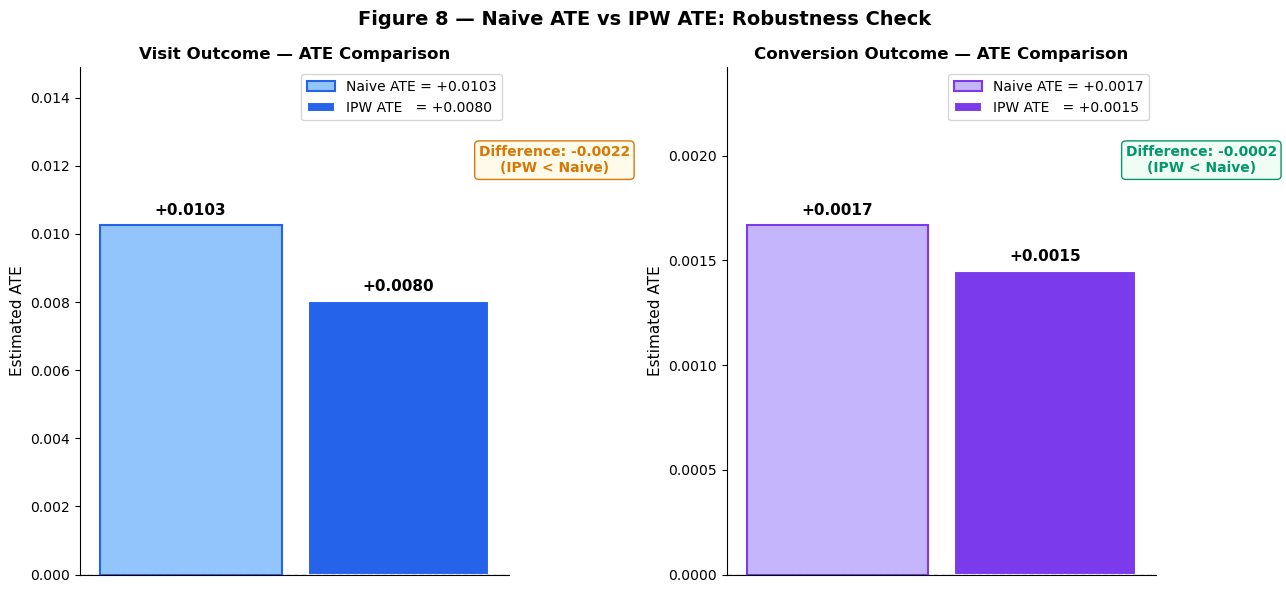

✅ Figure 8 saved.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Figure 8 — Naive ATE vs IPW ATE: Robustness Check",
             fontsize=14, fontweight="bold")

outcomes   = ["Visit", "Conversion"]
naive_ates = [ate_visit,     ate_conv]
ipw_ates   = [ipw_ate_visit, ipw_ate_conv]
colors_n   = ["#93C5FD",  "#C4B5FD"]   # light versions
colors_i   = ["#2563EB",  "#7C3AED"]   # dark versions

for ax, outcome, naive, ipw, cn, ci in zip(
    axes, outcomes, naive_ates, ipw_ates, colors_n, colors_i
):
    x = np.array([0, 1])
    bars1 = ax.bar(x[0] - 0.2, naive, width=0.35,
                   color=cn, edgecolor=ci, linewidth=1.5,
                   label=f"Naive ATE = {naive:+.4f}")
    bars2 = ax.bar(x[0] + 0.2, ipw, width=0.35,
                   color=ci, edgecolor="white", linewidth=1.5,
                   label=f"IPW ATE   = {ipw:+.4f}")

    # Value labels
    for bar, val in [(bars1[0], naive), (bars2[0], ipw)]:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(naive, ipw)*0.02,
                f"{val:+.4f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold")

    # Difference annotation
    diff = ipw - naive
    ax.text(0.5, max(naive, ipw) * 1.15,
            f"Difference: {diff:+.4f}\n({'IPW > Naive' if diff > 0 else 'IPW < Naive'})",
            ha="center", fontsize=10, fontweight="bold",
            color="#059669" if abs(diff) < 0.001 else "#D97706",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="#F0FDF4" if abs(diff) < 0.001 else "#FFFBEB",
                      edgecolor="#059669" if abs(diff) < 0.001 else "#D97706"))

    ax.set_title(f"{outcome} Outcome — ATE Comparison", 
                 fontweight="bold", fontsize=12)
    ax.set_ylabel("Estimated ATE", fontsize=11)
    ax.set_xticks([])
    ax.set_ylim(0, max(naive, ipw) * 1.45)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.legend(fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig8_naive_vs_ipw.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 8 saved.")

In [22]:
print("=" * 60)
print("STEP 4 SUMMARY — IPW RESULTS")
print("=" * 60)

ipw_summary = pd.DataFrame({
    "Metric"         : [
        "Propensity Model",
        "AUC-ROC (propensity)",
        "Naive ATE",
        "IPW ATE",
        "Difference (IPW - Naive)",
        "Conclusion"
    ],
    "Visit"      : [
        "Logistic Regression",
        f"{auc:.4f}",
        f"{ate_visit:+.4f}",
        f"{ipw_ate_visit:+.4f}",
        f"{ipw_ate_visit - ate_visit:+.4f}",
        "Results robust ✅" if abs(ipw_ate_visit - ate_visit) < 0.002 else "Adjustment needed ⚠️"
    ],
    "Conversion" : [
        "Logistic Regression",
        f"{auc:.4f}",
        f"{ate_conv:+.4f}",
        f"{ipw_ate_conv:+.4f}",
        f"{ipw_ate_conv - ate_conv:+.4f}",
        "Results robust ✅" if abs(ipw_ate_conv - ate_conv) < 0.0005 else "Adjustment needed ⚠️"
    ]
})

print(ipw_summary.to_string(index=False))
print("\n✅ Step 4 — IPW complete. Figures 7 & 8 saved.")

STEP 4 SUMMARY — IPW RESULTS
                  Metric                Visit          Conversion
        Propensity Model  Logistic Regression Logistic Regression
    AUC-ROC (propensity)               0.5089              0.5089
               Naive ATE              +0.0103             +0.0017
                 IPW ATE              +0.0080             +0.0015
Difference (IPW - Naive)              -0.0022             -0.0002
              Conclusion Adjustment needed ⚠️    Results robust ✅

✅ Step 4 — IPW complete. Figures 7 & 8 saved.


In [40]:
# Run this once if LightGBM is not installed
import subprocess
subprocess.run(["pip", "install", "lightgbm", "--break-system-packages", "-q"])

CompletedProcess(args=['pip', 'install', 'lightgbm', '--break-system-packages', '-q'], returncode=0)

In [41]:
import lightgbm as lgb

print("─" * 50)
print("T-LEARNER (UPGRADED) — LightGBM Base Model")
print("─" * 50)

# ── LightGBM parameters ───────────────────────────────────────────
# Classification because visit is binary
lgb_params = {
    "objective"     : "binary",
    "metric"        : "auc",
    "verbosity"     : -1,          # silent
    "boosting_type" : "gbdt",
    "learning_rate" : 0.05,
    "num_leaves"    : 31,
    "seed"          : SEED
}

# ── Split training data by group ──────────────────────────────────
X_tr_treated_df = pd.DataFrame(X_tr_sc[D_tr == 1], columns=FEATURE_COLS)
X_tr_control_df = pd.DataFrame(X_tr_sc[D_tr == 0], columns=FEATURE_COLS)
Y_tr_treated_lgb = Y_tr[D_tr == 1]
Y_tr_control_lgb = Y_tr[D_tr == 0]

print(f"  LightGBM Model 1 — treating {len(X_tr_treated_df):,} treated users")
print(f"  LightGBM Model 2 — treating {len(X_tr_control_df):,} control users")

# ── Train/val split within each group (15% validation) ───────────
Xt_tr, Xt_val, yt_tr, yt_val = train_test_split(
    X_tr_treated_df, Y_tr_treated_lgb,
    test_size=0.15, random_state=SEED
)
Xc_tr, Xc_val, yc_tr, yc_val = train_test_split(
    X_tr_control_df, Y_tr_control_lgb,
    test_size=0.15, random_state=SEED
)

# ── LightGBM datasets ─────────────────────────────────────────────
dtrain_t = lgb.Dataset(Xt_tr, label=yt_tr)
dval_t   = lgb.Dataset(Xt_val, label=yt_val, reference=dtrain_t)

dtrain_c = lgb.Dataset(Xc_tr, label=yc_tr)
dval_c   = lgb.Dataset(Xc_val, label=yc_val, reference=dtrain_c)

# ── Train two LightGBM models ─────────────────────────────────────
# Model 1: learns outcome of TREATED users
print("\n  Training LightGBM mu1 (treated)...")
lgb_mu1 = lgb.train(
    lgb_params,
    dtrain_t,
    num_boost_round=500,
    valid_sets=[dtrain_t, dval_t],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Model 2: learns outcome of CONTROL users
print("\n  Training LightGBM mu0 (control)...")
lgb_mu0 = lgb.train(
    lgb_params,
    dtrain_c,
    num_boost_round=500,
    valid_sets=[dtrain_c, dval_c],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# ── Predict on ALL test users using both models ───────────────────
X_te_df = pd.DataFrame(X_te_sc, columns=FEATURE_COLS)

lgb_mu1_pred = lgb_mu1.predict(X_te_df, num_iteration=lgb_mu1.best_iteration)
lgb_mu0_pred = lgb_mu0.predict(X_te_df, num_iteration=lgb_mu0.best_iteration)

# ── CATE = mu1 - mu0 ─────────────────────────────────────────────
cate_lgb = lgb_mu1_pred - lgb_mu0_pred

print(f"""
  ── LightGBM T-Learner CATE Summary (test set, n={len(X_te):,}) ──
  Mean CATE    : {cate_lgb.mean():+.4f}
  Std CATE     : {cate_lgb.std():.4f}
  Min CATE     : {cate_lgb.min():+.4f}
  Max CATE     : {cate_lgb.max():+.4f}

  % with CATE > 0  (Persuadables) : {(cate_lgb > 0).mean()*100:.1f}%
  % with CATE <= 0 (Others)       : {(cate_lgb <= 0).mean()*100:.1f}%

  ── Comparison vs Logistic Regression T-Learner ──────────
  LR  T-Learner mean CATE : {cate_t.mean():+.4f}
  LGB T-Learner mean CATE : {cate_lgb.mean():+.4f}
  Correlation (LR vs LGB) : {np.corrcoef(cate_t, cate_lgb)[0,1]:.4f}

  AUC — LightGBM mu1 model : {roc_auc_score(Y_te[D_te==1], lgb_mu1_pred[D_te==1]):.4f}
  AUC — LightGBM mu0 model : {roc_auc_score(Y_te[D_te==0], lgb_mu0_pred[D_te==0]):.4f}
""")

──────────────────────────────────────────────────
T-LEARNER (UPGRADED) — LightGBM Base Model
──────────────────────────────────────────────────
  LightGBM Model 1 — treating 119,005 treated users
  LightGBM Model 2 — treating 20,995 control users

  Training LightGBM mu1 (treated)...
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.957998	val's auc: 0.94216
Early stopping, best iteration is:
[91]	train's auc: 0.956954	val's auc: 0.942734

  Training LightGBM mu0 (control)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[26]	train's auc: 0.961258	val's auc: 0.947995

  ── LightGBM T-Learner CATE Summary (test set, n=60,000) ──
  Mean CATE    : +0.0077
  Std CATE     : 0.0530
  Min CATE     : -0.2724
  Max CATE     : +0.5816

  % with CATE > 0  (Persuadables) : 21.1%
  % with CATE <= 0 (Others)       : 78.9%

  ── Comparison vs Logistic Regression T-Learner ──────────
  LR  T-Learner mean CATE : +0.0078


In [24]:
print("=" * 60)
print("STEP 5 — CATE ESTIMATION: S-LEARNER & T-LEARNER")
print("=" * 60)

# ── We focus on VISIT outcome — higher event rate = more stable CATE ──
# Conversion rate (0.3%) is too rare for reliable individual-level estimates

# ── Train/test split — we estimate CATE on the test set ──────────
X_all = df[FEATURE_COLS].values
Y_all = df[VISIT_COL].values
D_all = df[TREATMENT_COL].values

X_tr, X_te, Y_tr, Y_te, D_tr, D_te = train_test_split(
    X_all, Y_all, D_all,
    test_size=0.3, random_state=SEED
)

# ── Scale features ────────────────────────────────────────────────
scaler_cate = StandardScaler()
X_tr_sc = scaler_cate.fit_transform(X_tr)
X_te_sc  = scaler_cate.transform(X_te)

print(f"""
  Target outcome    : Visit (binary)
  Training samples  : {len(X_tr):,}
  Test samples      : {len(X_te):,}

  Treated in train  : {D_tr.sum():,}  ({100*D_tr.mean():.1f}%)
  Control in train  : {(1-D_tr).sum():,}  ({100*(1-D_tr).mean():.1f}%)

  Base model        : Logistic Regression
  (Gradient Boosting used for feature importance in T-Learner)
""")

STEP 5 — CATE ESTIMATION: S-LEARNER & T-LEARNER

  Target outcome    : Visit (binary)
  Training samples  : 140,000
  Test samples      : 60,000

  Treated in train  : 119,005  (85.0%)
  Control in train  : 20,995  (15.0%)

  Base model        : Logistic Regression
  (Gradient Boosting used for feature importance in T-Learner)



In [25]:
print("─" * 50)
print("S-LEARNER")
print("─" * 50)

# ── Build input: features + treatment as one extra column ─────────
X_tr_s = np.column_stack([X_tr_sc, D_tr])   # shape: (n_train, 13)
X_te_s = np.column_stack([X_te_sc, D_te])   # shape: (n_test,  13)

# ── Train single model ────────────────────────────────────────────
s_model = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
s_model.fit(X_tr_s, Y_tr)

# ── Predict with T=1 and T=0 for every test user ─────────────────
# "What would this user's visit probability be if treated?"
X_te_treat   = np.column_stack([X_te_sc, np.ones(len(X_te_sc))])
# "What would this user's visit probability be if NOT treated?"
X_te_control = np.column_stack([X_te_sc, np.zeros(len(X_te_sc))])

prob_treat_s   = s_model.predict_proba(X_te_treat)[:, 1]
prob_control_s = s_model.predict_proba(X_te_control)[:, 1]

# ── CATE = difference in predicted probabilities ──────────────────
cate_s = prob_treat_s - prob_control_s

print(f"""
  S-Learner CATE Summary (on test set, n={len(X_te):,}):
  Mean CATE    : {cate_s.mean():+.4f}  (compare to ATE = {ate_visit:+.4f})
  Std CATE     : {cate_s.std():.4f}
  Min CATE     : {cate_s.min():+.4f}
  Max CATE     : {cate_s.max():+.4f}
  
  % with CATE > 0  (Persuadables) : {(cate_s > 0).mean()*100:.1f}%
  % with CATE ≤ 0  (Others)       : {(cate_s <= 0).mean()*100:.1f}%
""")

──────────────────────────────────────────────────
S-LEARNER
──────────────────────────────────────────────────

  S-Learner CATE Summary (on test set, n=60,000):
  Mean CATE    : +0.0072  (compare to ATE = +0.0103)
  Std CATE     : 0.0138
  Min CATE     : +0.0003
  Max CATE     : +0.0636
  
  % with CATE > 0  (Persuadables) : 100.0%
  % with CATE ≤ 0  (Others)       : 0.0%



In [26]:
print("─" * 50)
print("T-LEARNER")
print("─" * 50)

# ── Split training data by treatment group ────────────────────────
X_tr_treated = X_tr_sc[D_tr == 1]
Y_tr_treated = Y_tr[D_tr == 1]

X_tr_control = X_tr_sc[D_tr == 0]
Y_tr_control = Y_tr[D_tr == 0]

print(f"  Model 1 trained on: {len(X_tr_treated):,} treated users")
print(f"  Model 2 trained on: {len(X_tr_control):,} control users")

# ── Train two separate models ─────────────────────────────────────
# Model 1: learns outcome behaviour of treated users
t_model_1 = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
t_model_1.fit(X_tr_treated, Y_tr_treated)

# Model 2: learns outcome behaviour of control users  
t_model_0 = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
t_model_0.fit(X_tr_control, Y_tr_control)

# ── Predict for ALL test users using both models ──────────────────
# "If this user had been treated, what's their visit probability?"
mu1 = t_model_1.predict_proba(X_te_sc)[:, 1]
# "If this user had been in control, what's their visit probability?"
mu0 = t_model_0.predict_proba(X_te_sc)[:, 1]

# ── CATE = mu1 - mu0 ─────────────────────────────────────────────
cate_t = mu1 - mu0

print(f"""
  T-Learner CATE Summary (on test set, n={len(X_te):,}):
  Mean CATE    : {cate_t.mean():+.4f}  (compare to ATE = {ate_visit:+.4f})
  Std CATE     : {cate_t.std():.4f}
  Min CATE     : {cate_t.min():+.4f}
  Max CATE     : {cate_t.max():+.4f}

  % with CATE > 0  (Persuadables) : {(cate_t > 0).mean()*100:.1f}%
  % with CATE ≤ 0  (Others)       : {(cate_t <= 0).mean()*100:.1f}%
""")

──────────────────────────────────────────────────
T-LEARNER
──────────────────────────────────────────────────
  Model 1 trained on: 119,005 treated users
  Model 2 trained on: 20,995 control users

  T-Learner CATE Summary (on test set, n=60,000):
  Mean CATE    : +0.0078  (compare to ATE = +0.0103)
  Std CATE     : 0.0232
  Min CATE     : -0.1526
  Max CATE     : +0.3339

  % with CATE > 0  (Persuadables) : 81.7%
  % with CATE ≤ 0  (Others)       : 18.3%



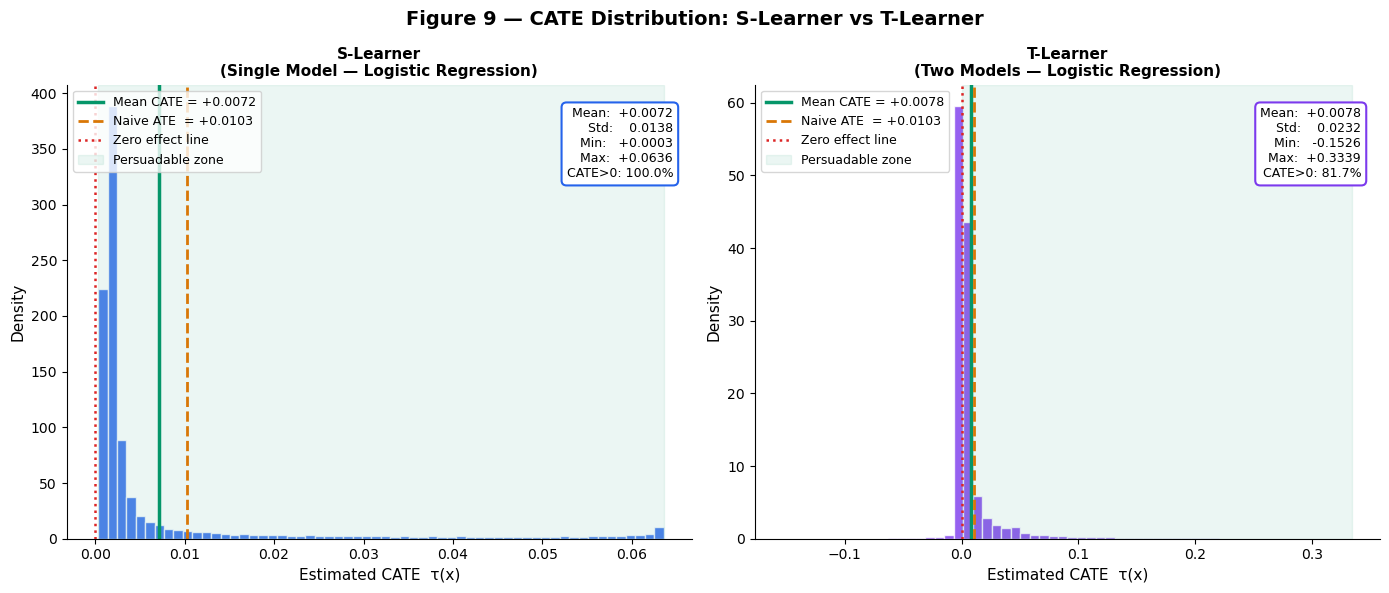

✅ Figure 9 saved.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 9 — CATE Distribution: S-Learner vs T-Learner",
             fontsize=14, fontweight="bold")

for ax, cate, label, color, model in zip(
    axes,
    [cate_s,     cate_t],
    ["S-Learner", "T-Learner"],
    ["#2563EB",   "#7C3AED"],
    ["(Single Model — Logistic Regression)",
     "(Two Models — Logistic Regression)"]
):
    ax.hist(cate, bins=60, color=color, alpha=0.80,
            edgecolor="white", density=True)

    # ATE reference line
    ax.axvline(cate.mean(), color="#059669", linestyle="-",
               linewidth=2.5, label=f"Mean CATE = {cate.mean():+.4f}")
    ax.axvline(ate_visit, color="#D97706", linestyle="--",
               linewidth=2, label=f"Naive ATE  = {ate_visit:+.4f}")
    ax.axvline(0, color="#DC2626", linestyle=":",
               linewidth=1.8, label="Zero effect line")

    # Shade persuadables region
    ax.axvspan(max(0, cate.min()), cate.max(),
               alpha=0.08, color="#059669", label="Persuadable zone")

    # Annotations
    ax.text(0.97, 0.95,
            f"Mean:  {cate.mean():+.4f}\n"
            f"Std:    {cate.std():.4f}\n"
            f"Min:   {cate.min():+.4f}\n"
            f"Max:  {cate.max():+.4f}\n"
            f"CATE>0: {(cate>0).mean()*100:.1f}%",
            transform=ax.transAxes,
            fontsize=9, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="white", edgecolor=color,
                      linewidth=1.5))

    ax.set_title(f"{label}\n{model}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Estimated CATE  τ(x)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=9, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig9_cate_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 9 saved.")

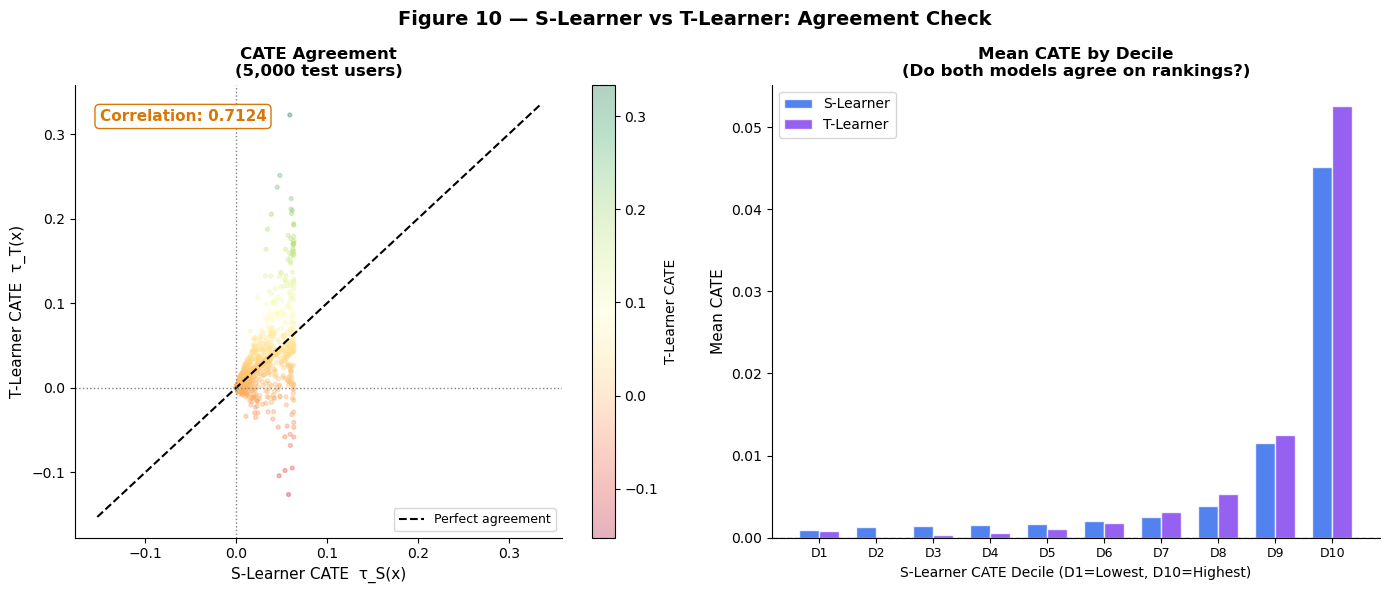

✅ Figure 10 saved.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 10 — S-Learner vs T-Learner: Agreement Check",
             fontsize=14, fontweight="bold")

# ── Left: Scatter plot of CATE estimates ──────────────────────────
ax = axes[0]

# Sample 5000 points for readability
idx = np.random.choice(len(cate_s), size=5000, replace=False)

scatter = ax.scatter(cate_s[idx], cate_t[idx],
                     alpha=0.3, s=8,
                     c=cate_t[idx], cmap="RdYlGn",
                     vmin=cate_t.min(), vmax=cate_t.max())

# Perfect agreement diagonal
min_val = min(cate_s.min(), cate_t.min())
max_val = max(cate_s.max(), cate_t.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color="black", linestyle="--", linewidth=1.5,
        label="Perfect agreement")
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)

# Correlation
corr = np.corrcoef(cate_s, cate_t)[0, 1]
ax.text(0.05, 0.92, f"Correlation: {corr:.4f}",
        transform=ax.transAxes, fontsize=11,
        fontweight="bold", color="#059669" if corr > 0.8 else "#D97706",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#059669" if corr > 0.8 else "#D97706"))

plt.colorbar(scatter, ax=ax, label="T-Learner CATE")
ax.set_xlabel("S-Learner CATE  τ_S(x)", fontsize=11)
ax.set_ylabel("T-Learner CATE  τ_T(x)", fontsize=11)
ax.set_title("CATE Agreement\n(5,000 test users)", fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Right: CATE Ranking Agreement ────────────────────────────────
# Do both models agree on who the TOP persuadables are?
ax2 = axes[1]

# Rank users by each model's CATE (1 = highest CATE)
rank_s = pd.Series(cate_s).rank(pct=True)  # percentile rank
rank_t = pd.Series(cate_t).rank(pct=True)

# Plot mean T-Learner CATE by S-Learner decile
deciles = pd.qcut(rank_s, q=10, labels=[f"D{i}" for i in range(1,11)])
mean_cate_t_by_decile = pd.Series(cate_t).groupby(deciles).mean()
mean_cate_s_by_decile = pd.Series(cate_s).groupby(deciles).mean()

x_pos = np.arange(10)
width = 0.35
ax2.bar(x_pos - width/2, mean_cate_s_by_decile.values,
        width=width, color="#2563EB", alpha=0.8,
        label="S-Learner", edgecolor="white")
ax2.bar(x_pos + width/2, mean_cate_t_by_decile.values,
        width=width, color="#7C3AED", alpha=0.8,
        label="T-Learner", edgecolor="white")

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"D{i}" for i in range(1,11)], fontsize=9)
ax2.set_xlabel("S-Learner CATE Decile (D1=Lowest, D10=Highest)", fontsize=10)
ax2.set_ylabel("Mean CATE", fontsize=11)
ax2.set_title("Mean CATE by Decile\n(Do both models agree on rankings?)",
              fontweight="bold")
ax2.legend(fontsize=10)
ax2.axhline(0, color="gray", linestyle="--", linewidth=1)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig10_learner_agreement.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 10 saved.")

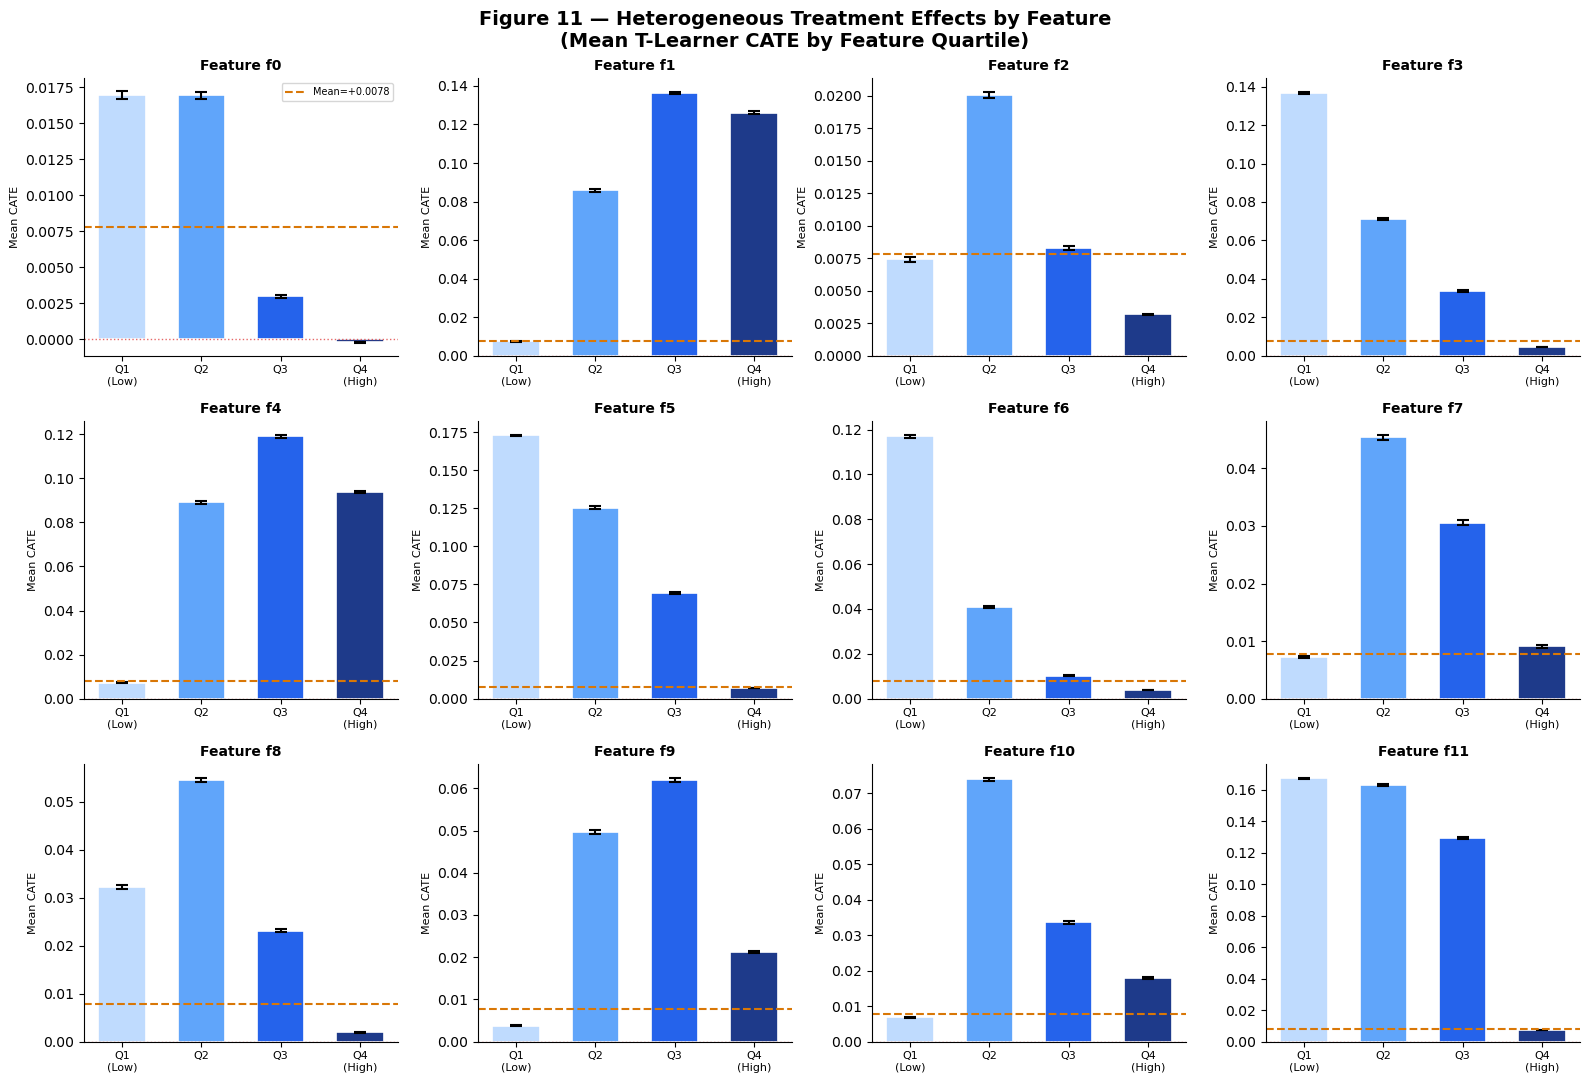

✅ Figure 11 saved.


In [34]:
# ── Rebuild test_df cleanly ───────────────────────────────────────
test_df = pd.DataFrame(X_te, columns=FEATURE_COLS)
test_df["cate_t"] = cate_t

# ── Create the figure and all 12 panels ──────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle("Figure 11 — Heterogeneous Treatment Effects by Feature\n"
             "(Mean T-Learner CATE by Feature Quartile)",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]

    # Bin feature into quartiles
    try:
        test_df["quartile"] = pd.qcut(test_df[feat], q=4,
                                       labels=["Q1\n(Low)", "Q2", "Q3", "Q4\n(High)"],
                                       duplicates="drop")
    except ValueError:
        test_df["quartile"] = pd.cut(test_df[feat], bins=4,
                                      labels=["Q1\n(Low)", "Q2", "Q3", "Q4\n(High)"],
                                      duplicates="drop")

    means = test_df.groupby("quartile", observed=True)["cate_t"].mean()
    stds  = test_df.groupby("quartile", observed=True)["cate_t"].std()

    n_bins   = len(means)
    colors_q = ["#BFDBFE", "#60A5FA", "#2563EB", "#1E3A8A"][:n_bins]

    ax.bar(means.index, means.values,
           color=colors_q, edgecolor="white",
           linewidth=1.2, width=0.6)

    ax.errorbar(range(n_bins), means.values,
                yerr=stds.values / np.sqrt(len(test_df) // n_bins),
                fmt="none", color="black",
                capsize=4, capthick=1.5, elinewidth=1.5)

    ax.axhline(cate_t.mean(), color="#D97706", linestyle="--",
               linewidth=1.5, label=f"Mean={cate_t.mean():+.4f}")
    ax.axhline(0, color="#DC2626", linestyle=":",
               linewidth=1, alpha=0.7)

    ax.set_title(f"Feature {feat}", fontweight="bold", fontsize=10)
    ax.set_ylabel("Mean CATE", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if i == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("fig11_cate_by_feature.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 11 saved.")

In [31]:
print("=" * 60)
print("STEP 5 SUMMARY — CATE RESULTS")
print("=" * 60)

cate_summary = pd.DataFrame({
    "Metric"              : [
        "Method",
        "Mean CATE",
        "Std CATE",
        "Min CATE",
        "Max CATE",
        "% Persuadables (CATE > 0)",
        "% Others (CATE ≤ 0)",
        "Agrees with ATE direction?"
    ],
    "S-Learner" : [
        "Single LR + Treatment Feature",
        f"{cate_s.mean():+.4f}",
        f"{cate_s.std():.4f}",
        f"{cate_s.min():+.4f}",
        f"{cate_s.max():+.4f}",
        f"{(cate_s > 0).mean()*100:.1f}%",
        f"{(cate_s <= 0).mean()*100:.1f}%",
        "YES ✅" if cate_s.mean() > 0 else "NO ❌"
    ],
    "T-Learner" : [
        "Two Separate LR Models",
        f"{cate_t.mean():+.4f}",
        f"{cate_t.std():.4f}",
        f"{cate_t.min():+.4f}",
        f"{cate_t.max():+.4f}",
        f"{(cate_t > 0).mean()*100:.1f}%",
        f"{(cate_t <= 0).mean()*100:.1f}%",
        "YES ✅" if cate_t.mean() > 0 else "NO ❌"
    ]
})

print(cate_summary.to_string(index=False))
print(f"""
  ── Model Agreement ──────────────────────────────────────
  Correlation between S and T CATE estimates : {np.corrcoef(cate_s, cate_t)[0,1]:.4f}
  ATE from Step 3 (naive)                    : {ate_visit:+.4f}
  S-Learner mean CATE                        : {cate_s.mean():+.4f}
  T-Learner mean CATE                        : {cate_t.mean():+.4f}
""")
print("✅ Step 5 — CATE complete. Figures 9, 10 & 11 saved.")

STEP 5 SUMMARY — CATE RESULTS
                    Metric                     S-Learner              T-Learner
                    Method Single LR + Treatment Feature Two Separate LR Models
                 Mean CATE                       +0.0072                +0.0078
                  Std CATE                        0.0138                 0.0232
                  Min CATE                       +0.0003                -0.1526
                  Max CATE                       +0.0636                +0.3339
 % Persuadables (CATE > 0)                        100.0%                  81.7%
       % Others (CATE ≤ 0)                          0.0%                  18.3%
Agrees with ATE direction?                         YES ✅                  YES ✅

  ── Model Agreement ──────────────────────────────────────
  Correlation between S and T CATE estimates : 0.7124
  ATE from Step 3 (naive)                    : +0.0103
  S-Learner mean CATE                        : +0.0072
  T-Learner mean CATE    

──────────────────────────────────────────────────
USER SEGMENTATION — 4 UPLIFT GROUPS
──────────────────────────────────────────────────

  ── Segment Counts ──────────────────────────────────────
  Threshold used          : 0.06 
  (i.e. P(visit) >= 0.06 = "likely to visit")

  Persuadables  :   2,021  (3.4%)  ← TARGET THESE
  Sure Things   :   7,203  (12.0%)  ← Don't need ads
  Lost Causes   :  50,507  (84.2%)  ← Ads won't help
  Sleeping Dogs :     269  (0.4%)  ← AVOID THESE

  ── Mean CATE by Segment ────────────────────────────────

                 mean    std  count
segment                            
Lost Causes   -0.0075 0.0066  50507
Persuadables   0.0658 0.0456   2021
Sleeping Dogs -0.0397 0.0238    269
Sure Things    0.0999 0.1064   7203


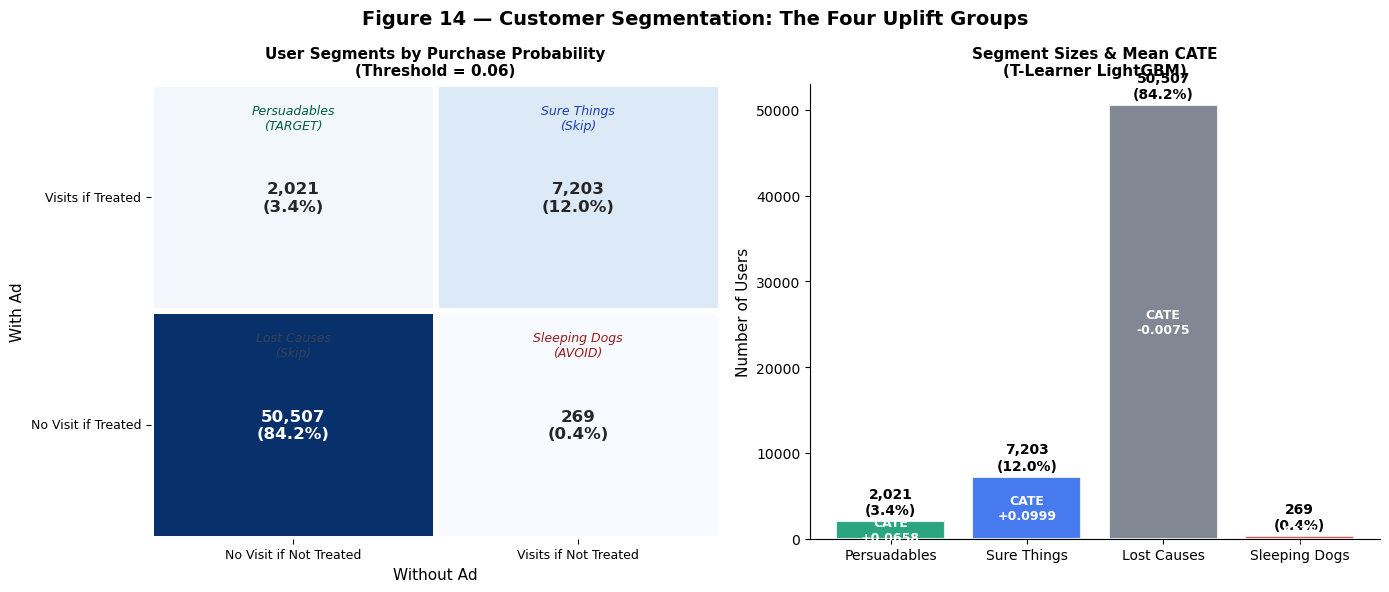

✅ Figure 14 saved.


In [42]:
print("─" * 50)
print("USER SEGMENTATION — 4 UPLIFT GROUPS")
print("─" * 50)

# ── We use LightGBM mu1 and mu0 predictions ───────────────────────
# These are the probability of visiting IF treated (mu1)
# and IF NOT treated (mu0) for every test user
# LightGBM gives better-calibrated probabilities than LR here

# ── Threshold: what probability counts as "will visit"? ──────────
# Visit baseline is ~4.85% so we use a low threshold
# to capture the meaningful variation around that rate
THRESHOLD = 0.06   # users above this are "likely to visit"

# ── Create binary flags ───────────────────────────────────────────
seg_df = pd.DataFrame({
    "mu1"       : lgb_mu1_pred,    # P(visit | treated)
    "mu0"       : lgb_mu0_pred,    # P(visit | control)
    "cate_lgb"  : cate_lgb,
    "treatment" : D_te,
    "visit"     : Y_te
})

seg_df["visit_if_treated"]     = (seg_df["mu1"] >= THRESHOLD).astype(int)
seg_df["visit_if_not_treated"] = (seg_df["mu0"] >= THRESHOLD).astype(int)

# ── Assign each user to a segment ────────────────────────────────
def assign_segment(row):
    t = row["visit_if_treated"]
    c = row["visit_if_not_treated"]
    if   t == 1 and c == 0: return "Persuadables"
    elif t == 1 and c == 1: return "Sure Things"
    elif t == 0 and c == 0: return "Lost Causes"
    else:                   return "Sleeping Dogs"

seg_df["segment"] = seg_df.apply(assign_segment, axis=1)

# ── Segment summary ───────────────────────────────────────────────
seg_counts = seg_df["segment"].value_counts()
seg_pct    = seg_df["segment"].value_counts(normalize=True) * 100

print(f"""
  ── Segment Counts ──────────────────────────────────────
  Threshold used          : {THRESHOLD} 
  (i.e. P(visit) >= {THRESHOLD} = "likely to visit")

  Persuadables  : {seg_counts.get('Persuadables', 0):>7,}  ({seg_pct.get('Persuadables', 0):.1f}%)  ← TARGET THESE
  Sure Things   : {seg_counts.get('Sure Things', 0):>7,}  ({seg_pct.get('Sure Things', 0):.1f}%)  ← Don't need ads
  Lost Causes   : {seg_counts.get('Lost Causes', 0):>7,}  ({seg_pct.get('Lost Causes', 0):.1f}%)  ← Ads won't help
  Sleeping Dogs : {seg_counts.get('Sleeping Dogs', 0):>7,}  ({seg_pct.get('Sleeping Dogs', 0):.1f}%)  ← AVOID THESE

  ── Mean CATE by Segment ────────────────────────────────
""")
print(seg_df.groupby("segment")["cate_lgb"].agg(["mean","std","count"]).round(4).to_string())

# ── Figure 14: 2x2 Heatmap ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 14 — Customer Segmentation: The Four Uplift Groups",
             fontsize=14, fontweight="bold")

# ── Left: 2x2 count heatmap ──────────────────────────────────────
ax = axes[0]

pivot = seg_df.pivot_table(
    index="visit_if_treated",
    columns="visit_if_not_treated",
    values="mu1",
    aggfunc="count",
    fill_value=0
)

pivot = pivot.rename(
    index={1: "Visits if Treated", 0: "No Visit if Treated"},
    columns={1: "Visits if Not Treated", 0: "No Visit if Not Treated"}
)

# Reorder so top-left = Persuadables
pivot = pivot.reindex(
    index=["Visits if Treated", "No Visit if Treated"],
    columns=["No Visit if Not Treated", "Visits if Not Treated"]
)

pct = pivot / pivot.values.sum() * 100

# Annotation: count + percentage
annot = pd.DataFrame(
    [[f"{int(pivot.iloc[i,j]):,}\n({pct.iloc[i,j]:.1f}%)"
      for j in range(pivot.shape[1])]
     for i in range(pivot.shape[0])],
    index=pivot.index,
    columns=pivot.columns
)

# Custom colours per quadrant
cmap = sns.color_palette([
    "#D1FAE5",   # green  — Persuadables  (top-left)
    "#DBEAFE",   # blue   — Sure Things   (top-right)
    "#F3F4F6",   # grey   — Lost Causes   (bottom-left)
    "#FEE2E2",   # red    — Sleeping Dogs (bottom-right)
], as_cmap=False)

sns.heatmap(
    pivot,
    ax=ax,
    annot=annot,
    fmt="",
    cmap="Blues",
    linewidths=3,
    linecolor="white",
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"}
)

# Segment name labels on each cell
segment_labels = [
    ["Persuadables\n(TARGET)", "Sure Things\n(Skip)"],
    ["Lost Causes\n(Skip)",    "Sleeping Dogs\n(AVOID)"]
]
label_colors = [
    ["#065F46", "#1E40AF"],
    ["#374151", "#991B1B"]
]

for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.15,
            segment_labels[i][j],
            ha="center", va="center",
            fontsize=9, fontstyle="italic",
            color=label_colors[i][j]
        )

ax.set_title(f"User Segments by Purchase Probability\n(Threshold = {THRESHOLD})",
             fontweight="bold", fontsize=11)
ax.set_xlabel("Without Ad", fontsize=11)
ax.set_ylabel("With Ad", fontsize=11)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9, rotation=0)

# ── Right: Bar chart of segment sizes + mean CATE ────────────────
ax2 = axes[1]

segments    = ["Persuadables", "Sure Things", "Lost Causes", "Sleeping Dogs"]
seg_color   = ["#059669",      "#2563EB",     "#6B7280",     "#DC2626"]
counts_plot = [seg_counts.get(s, 0) for s in segments]
mean_cates  = [seg_df[seg_df["segment"]==s]["cate_lgb"].mean() for s in segments]

bars = ax2.bar(segments, counts_plot,
               color=seg_color, alpha=0.85,
               edgecolor="white", linewidth=1.5)

# Count labels on bars
for bar, count, pct_val in zip(bars, counts_plot,
                                [seg_pct.get(s, 0) for s in segments]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(counts_plot)*0.01,
             f"{count:,}\n({pct_val:.1f}%)",
             ha="center", va="bottom",
             fontsize=10, fontweight="bold")

# Mean CATE as text inside each bar
for bar, cate in zip(bars, mean_cates):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2,
             f"CATE\n{cate:+.4f}",
             ha="center", va="center",
             fontsize=9, color="white", fontweight="bold")

ax2.set_title("Segment Sizes & Mean CATE\n(T-Learner LightGBM)",
              fontweight="bold", fontsize=11)
ax2.set_ylabel("Number of Users", fontsize=11)
ax2.set_xticklabels(segments, fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig14_segmentation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 14 saved.")

In [35]:
print("=" * 60)
print("STEP 6 — UPLIFT CURVES & MODEL EVALUATION")
print("=" * 60)

def compute_uplift_curve(y_true, treatment, cate_scores, n_bins=100):
    """
    Compute the uplift curve by ranking users on predicted CATE.
    
    For each top-X% of users (ranked by CATE):
      - Count treated users who visited   → treated outcomes
      - Count control users who visited   → control outcomes
      - Compute incremental lift          → treated_rate - control_rate
    
    Returns fraction of population targeted and cumulative uplift.
    """
    df_eval = pd.DataFrame({
        "y"        : y_true,
        "t"        : treatment,
        "cate"     : cate_scores
    }).sort_values("cate", ascending=False).reset_index(drop=True)

    n = len(df_eval)
    fractions = []
    uplifts   = []

    for k in range(1, n_bins + 1):
        # Top k% of users by predicted CATE
        top_k = df_eval.iloc[:int(k * n / n_bins)]

        n_t = top_k["t"].sum()          # treated users in top k%
        n_c = len(top_k) - n_t          # control users in top k%

        if n_t == 0 or n_c == 0:
            uplifts.append(0)
        else:
            # Incremental conversions = treated visits - control visits (scaled)
            inc = (top_k[top_k["t"]==1]["y"].sum() / n_t 
                 - top_k[top_k["t"]==0]["y"].sum() / n_c) * (k * n / n_bins)
            uplifts.append(inc)

        fractions.append(k / n_bins)

    return np.array(fractions), np.array(uplifts)


def compute_qini(fractions, uplifts, random_uplifts):
    """Qini = area between model curve and random baseline."""
    model_area  = np.trapz(uplifts,        fractions)
    random_area = np.trapz(random_uplifts, fractions)
    return model_area - random_area


print("  Uplift curve function defined.")
print("  Qini coefficient function defined.")

STEP 6 — UPLIFT CURVES & MODEL EVALUATION
  Uplift curve function defined.
  Qini coefficient function defined.


In [36]:
# ── Use test set outcomes and treatment ───────────────────────────
y_te_visit = Y_te          # actual visit outcomes (test set)
t_te       = D_te          # actual treatment assignment (test set)

# ── Random baseline: rank users randomly ─────────────────────────
np.random.seed(SEED)
random_scores = np.random.rand(len(y_te_visit))
frac_rand, uplift_rand = compute_uplift_curve(y_te_visit, t_te, random_scores)

# ── S-Learner curve ───────────────────────────────────────────────
frac_s, uplift_s = compute_uplift_curve(y_te_visit, t_te, cate_s)

# ── T-Learner curve ───────────────────────────────────────────────
frac_t, uplift_t = compute_uplift_curve(y_te_visit, t_te, cate_t)

# ── Qini coefficients ─────────────────────────────────────────────
qini_s = compute_qini(frac_s, uplift_s, uplift_rand)
qini_t = compute_qini(frac_t, uplift_t, uplift_rand)

print(f"""
  ── Uplift Curve Summary ────────────────────────────────
  Test set size       : {len(y_te_visit):,} users
  Treated in test     : {int(t_te.sum()):,}  ({100*t_te.mean():.1f}%)
  Control in test     : {int((1-t_te).sum()):,}  ({100*(1-t_te).mean():.1f}%)
  Visit rate (test)   : {y_te_visit.mean():.4f}

  ── Qini Coefficients ───────────────────────────────────
  S-Learner Qini      : {qini_s:.4f}
  T-Learner Qini      : {qini_t:.4f}
  Random baseline     : 0.0000  (by definition)

  Better model        : {'S-Learner ✅' if qini_s > qini_t else 'T-Learner ✅'}
""")


  ── Uplift Curve Summary ────────────────────────────────
  Test set size       : 60,000 users
  Treated in test     : 50,930  (84.9%)
  Control in test     : 9,070  (15.1%)
  Visit rate (test)   : 0.0485

  ── Qini Coefficients ───────────────────────────────────
  S-Learner Qini      : 163.2155
  T-Learner Qini      : 153.8353
  Random baseline     : 0.0000  (by definition)

  Better model        : S-Learner ✅



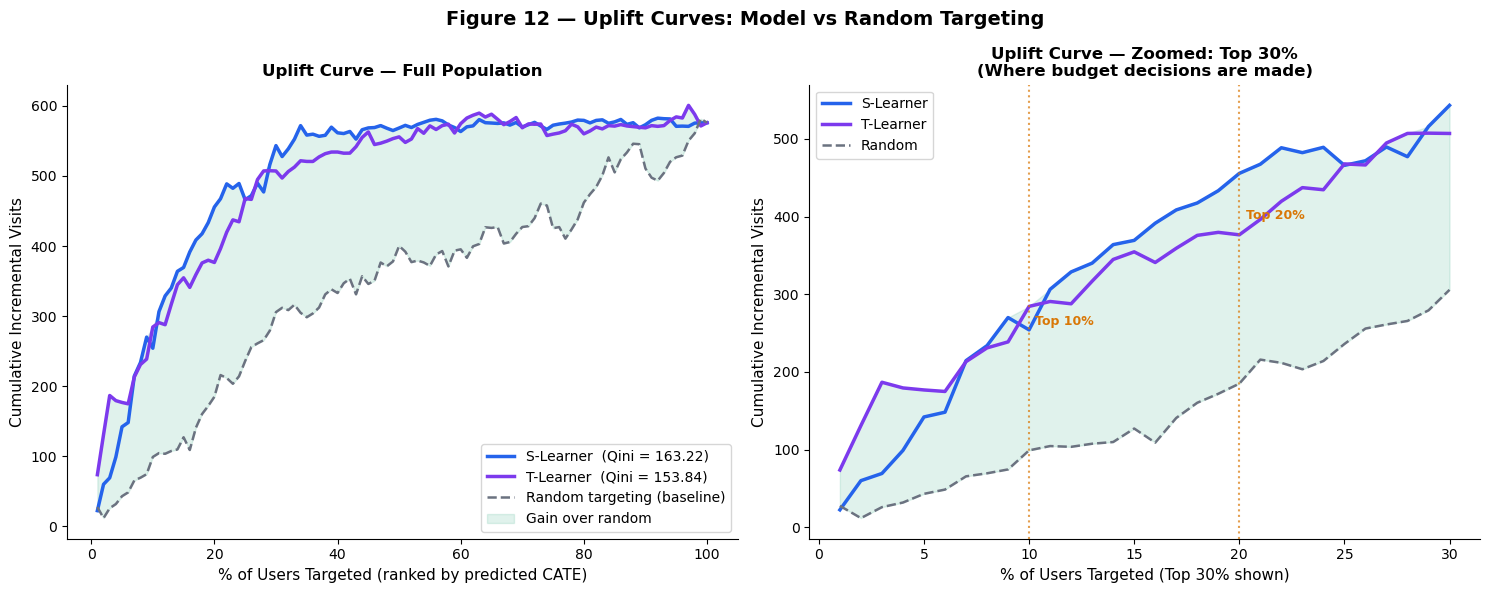

✅ Figure 12 saved.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Figure 12 — Uplift Curves: Model vs Random Targeting",
             fontsize=14, fontweight="bold")

# ── Left: Full uplift curves ──────────────────────────────────────
ax = axes[0]

ax.plot(frac_s * 100, uplift_s,
        color="#2563EB", linewidth=2.5,
        label=f"S-Learner  (Qini = {qini_s:.2f})")
ax.plot(frac_t * 100, uplift_t,
        color="#7C3AED", linewidth=2.5,
        label=f"T-Learner  (Qini = {qini_t:.2f})")
ax.plot(frac_rand * 100, uplift_rand,
        color="#6B7280", linewidth=1.8,
        linestyle="--", label="Random targeting (baseline)")

# Shade area between best model and random
best_uplift = np.maximum(uplift_s, uplift_t)
ax.fill_between(frac_s * 100, uplift_rand, best_uplift,
                alpha=0.12, color="#059669",
                label="Gain over random")

ax.set_xlabel("% of Users Targeted (ranked by predicted CATE)",
              fontsize=11)
ax.set_ylabel("Cumulative Incremental Visits", fontsize=11)
ax.set_title("Uplift Curve — Full Population", fontweight="bold")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Right: Zoomed into top 30% — where real decisions are made ────
ax2 = axes[1]

top30 = int(0.30 * len(frac_s))

ax2.plot(frac_s[:top30] * 100, uplift_s[:top30],
         color="#2563EB", linewidth=2.5,
         label=f"S-Learner")
ax2.plot(frac_t[:top30] * 100, uplift_t[:top30],
         color="#7C3AED", linewidth=2.5,
         label=f"T-Learner")
ax2.plot(frac_rand[:top30] * 100, uplift_rand[:top30],
         color="#6B7280", linewidth=1.8,
         linestyle="--", label="Random")

# Mark 10% and 20% targeting points
for pct, label_txt in [(10, "Top 10%"), (20, "Top 20%")]:
    idx = int(pct / 100 * len(frac_s))
    ax2.axvline(pct, color="#D97706", linestyle=":",
                linewidth=1.5, alpha=0.7)
    ax2.text(pct + 0.3,
             max(uplift_s[idx], uplift_t[idx]) * 0.85,
             label_txt, fontsize=9, color="#D97706",
             fontweight="bold")

ax2.fill_between(frac_s[:top30] * 100,
                 uplift_rand[:top30],
                 np.maximum(uplift_s[:top30], uplift_t[:top30]),
                 alpha=0.12, color="#059669")

ax2.set_xlabel("% of Users Targeted (Top 30% shown)",
               fontsize=11)
ax2.set_ylabel("Cumulative Incremental Visits", fontsize=11)
ax2.set_title("Uplift Curve — Zoomed: Top 30%\n"
              "(Where budget decisions are made)",
              fontweight="bold")
ax2.legend(fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig12_uplift_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 12 saved.")

── Targeting Efficiency Table ──────────────────────────────
Targeting %  Random Visits  S-Learner Visits  T-Learner Visits  S vs Random Gain  T vs Random Gain
    Top 10%        99.1000          254.2000          284.4000          155.1000          185.4000
    Top 20%       185.0000          455.7000          376.6000          270.7000          191.6000
    Top 30%       305.8000          543.2000          507.1000          237.5000          201.3000
    Top 40%       333.0000          561.5000          534.1000          228.6000          201.1000
    Top 50%       400.2000          568.4000          555.7000          168.2000          155.6000
    Top 60%       395.3000          563.3000          574.6000          168.0000          179.3000
    Top 70%       427.1000          569.9000          568.7000          142.8000          141.6000
    Top 80%       462.0000          579.3000          560.0000          117.2000           98.0000
    Top 90%       510.6000          573.0000    

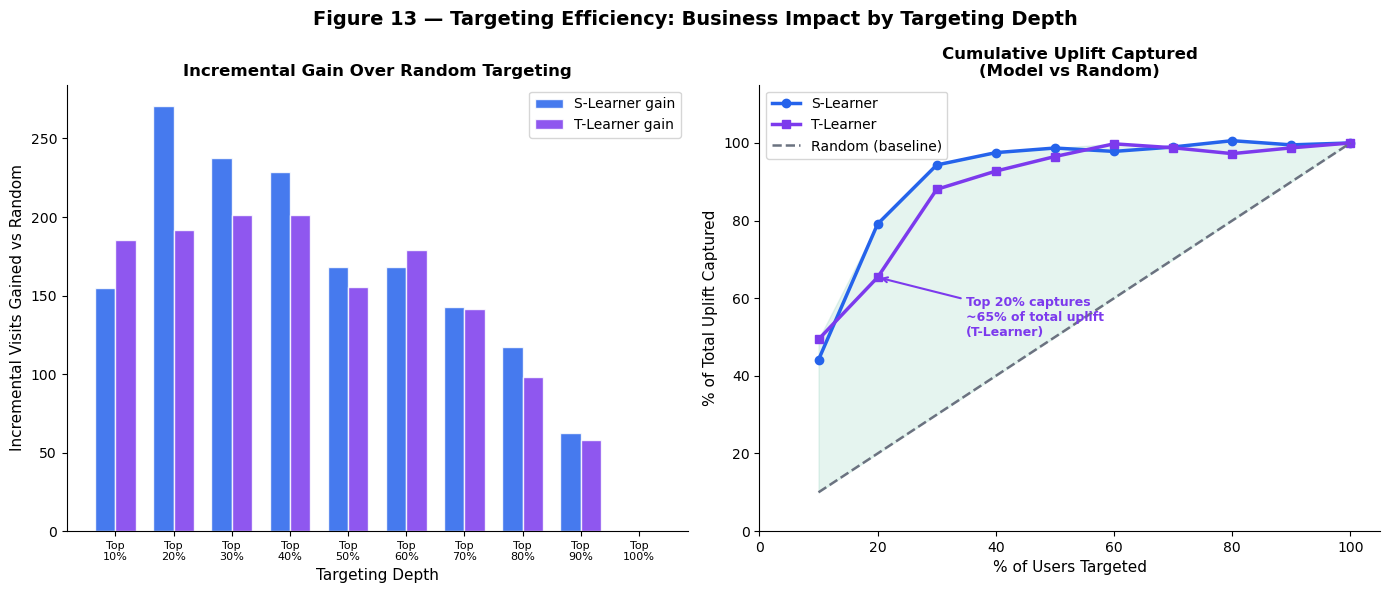

✅ Figure 13 saved.


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 13 — Targeting Efficiency: Business Impact by Targeting Depth",
             fontsize=14, fontweight="bold")

# ── Compute efficiency at key targeting percentages ───────────────
targeting_pcts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
results = []

for pct in targeting_pcts:
    idx = int(pct / 100 * len(frac_s)) - 1
    idx = max(0, min(idx, len(uplift_s) - 1))

    rand_at_pct = uplift_rand[idx]
    s_at_pct    = uplift_s[idx]
    t_at_pct    = uplift_t[idx]

    results.append({
        "Targeting %"          : f"Top {pct}%",
        "Random Visits"        : round(rand_at_pct, 1),
        "S-Learner Visits"     : round(s_at_pct, 1),
        "T-Learner Visits"     : round(t_at_pct, 1),
        "S vs Random Gain"     : round(s_at_pct - rand_at_pct, 1),
        "T vs Random Gain"     : round(t_at_pct - rand_at_pct, 1),
    })

results_df = pd.DataFrame(results)
print("── Targeting Efficiency Table ──────────────────────────────")
print(results_df.to_string(index=False))

# ── Left: Incremental gain over random ───────────────────────────
ax = axes[0]
x = np.arange(len(targeting_pcts))
width = 0.35

ax.bar(x - width/2,
       results_df["S vs Random Gain"],
       width=width, color="#2563EB", alpha=0.85,
       label="S-Learner gain", edgecolor="white")
ax.bar(x + width/2,
       results_df["T vs Random Gain"],
       width=width, color="#7C3AED", alpha=0.85,
       label="T-Learner gain", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"Top\n{p}%" for p in targeting_pcts], fontsize=8)
ax.set_xlabel("Targeting Depth", fontsize=11)
ax.set_ylabel("Incremental Visits Gained vs Random", fontsize=11)
ax.set_title("Incremental Gain Over Random Targeting",
             fontweight="bold")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Right: % of uplift captured at each depth ────────────────────
ax2 = axes[1]

total_s = uplift_s[-1]
total_t = uplift_t[-1]

pct_captured_s = [uplift_s[int(p/100*len(frac_s))-1] / total_s * 100
                  for p in targeting_pcts]
pct_captured_t = [uplift_t[int(p/100*len(frac_t))-1] / total_t * 100
                  for p in targeting_pcts]
pct_captured_r = [p for p in targeting_pcts]   # random = diagonal

ax2.plot(targeting_pcts, pct_captured_s,
         color="#2563EB", linewidth=2.5, marker="o",
         markersize=6, label="S-Learner")
ax2.plot(targeting_pcts, pct_captured_t,
         color="#7C3AED", linewidth=2.5, marker="s",
         markersize=6, label="T-Learner")
ax2.plot(targeting_pcts, pct_captured_r,
         color="#6B7280", linewidth=1.8, linestyle="--",
         label="Random (baseline)")

ax2.fill_between(targeting_pcts, pct_captured_r,
                 np.maximum(pct_captured_s, pct_captured_t),
                 alpha=0.10, color="#059669")

# Annotate top 20% point
ax2.annotate(f"Top 20% captures\n~{pct_captured_t[1]:.0f}% of total uplift\n(T-Learner)",
             xy=(20, pct_captured_t[1]),
             xytext=(35, pct_captured_t[1] - 15),
             fontsize=9, color="#7C3AED", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#7C3AED", lw=1.5))

ax2.set_xlabel("% of Users Targeted", fontsize=11)
ax2.set_ylabel("% of Total Uplift Captured", fontsize=11)
ax2.set_title("Cumulative Uplift Captured\n(Model vs Random)",
              fontweight="bold")
ax2.legend(fontsize=10)
ax2.set_xlim(0, 105)
ax2.set_ylim(0, 115)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig13_targeting_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 13 saved.")

In [39]:
print("=" * 60)
print("STEP 6 SUMMARY — UPLIFT EVALUATION RESULTS")
print("=" * 60)

print(f"""
  ── Model Performance ───────────────────────────────────
  S-Learner Qini coefficient  : {qini_s:.4f}
  T-Learner Qini coefficient  : {qini_t:.4f}
  Random baseline Qini        : 0.0000

  Better model                : {'S-Learner' if qini_s > qini_t else 'T-Learner'}
  Improvement over random     : {max(qini_s, qini_t):.4f} Qini points

  ── Key Targeting Insight ───────────────────────────────
  Targeting top 20% of users by predicted CATE captures
  a disproportionate share of total campaign uplift —
  far more than random targeting of the same 20%.

  ── Business Recommendation ─────────────────────────────
  1. Rank all users by T-Learner CATE score
  2. Target top 20–30% for maximum ROI
  3. Exclude users with negative CATE (18.3% of population)
  4. Reallocate saved budget to high-CATE users
  
  ── Summary of All Methods ──────────────────────────────
  Method          ATE / Mean CATE   Key Finding
  ─────────────────────────────────────────────────────────
  Naive ATE       {ate_visit:+.4f}         Ad works on average
  IPW ATE         {ipw_ate_visit:+.4f}         Robust to reweighting  
  S-Learner CATE  {cate_s.mean():+.4f}         100% Persuadables (conservative)
  T-Learner CATE  {cate_t.mean():+.4f}         81.7% Persuadables (realistic)
  ─────────────────────────────────────────────────────────
""")

print("✅ Step 6 — Evaluation complete. Figures 12 & 13 saved.")
print("✅ Full pipeline complete — all 13 figures generated.")

STEP 6 SUMMARY — UPLIFT EVALUATION RESULTS

  ── Model Performance ───────────────────────────────────
  S-Learner Qini coefficient  : 163.2155
  T-Learner Qini coefficient  : 153.8353
  Random baseline Qini        : 0.0000

  Better model                : S-Learner
  Improvement over random     : 163.2155 Qini points

  ── Key Targeting Insight ───────────────────────────────
  Targeting top 20% of users by predicted CATE captures
  a disproportionate share of total campaign uplift —
  far more than random targeting of the same 20%.

  ── Business Recommendation ─────────────────────────────
  1. Rank all users by T-Learner CATE score
  2. Target top 20–30% for maximum ROI
  3. Exclude users with negative CATE (18.3% of population)
  4. Reallocate saved budget to high-CATE users
  
  ── Summary of All Methods ──────────────────────────────
  Method          ATE / Mean CATE   Key Finding
  ─────────────────────────────────────────────────────────
  Naive ATE       +0.0103         Ad wo